# 서울 아파트 실거래가 데이터 탐색적 분석(EDA)

본 노트북은 서울시 아파트 매매가 분석 프로그램 개발의 사전 단계로서, 전처리가 완료된
실거래가 데이터에 대한 탐색적 데이터 분석(Exploratory Data Analysis)을 수행한다.

**분석 목적**

1. 데이터의 구조 및 분포 특성을 파악한다.
2. 아파트 가격을 결정하는 주요 요인(입지, 면적, 건물 연식 등)을 식별한다.
3. 후속 머신러닝 모델링에 활용할 변수의 적합성과 전처리 방향을 검토한다.

**사용 도구**

- Python, pandas, matplotlib (분석 지침에 따라 도구를 한정한다)

**데이터 개요**

- 파일: `아파트_실거래_전처리_2023_2025.csv`
- 대상 지역: 서울특별시 25개 자치구
- 대상 기간: 2023년 1월 ~ 2025년 12월 (계약년월 기준)
- 관측치: 약 142,000건의 아파트 매매 실거래 내역



## 1. 분석 환경 설정

분석에 필요한 라이브러리를 임포트하고, 그래프에 한글이 정상 출력되도록 폰트를 설정한다.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (환경에 존재하는 한글 지원 폰트를 탐색하여 적용)
_font_candidates = ['Malgun Gothic', 'NanumGothic', 'AppleGothic',
                    'Noto Sans CJK KR', 'Noto Sans CJK JP']
_available = {f.name for f in fm.fontManager.ttflist}
for _f in _font_candidates:
    if _f in _available:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

print('적용 폰트:', plt.rcParams['font.family'])


적용 폰트: ['Malgun Gothic']


## 2. 데이터 적재 및 기초 점검

전처리가 완료된 CSV 파일을 불러온 뒤, 데이터의 크기와 컬럼 구성을 확인한다.


In [3]:
# 데이터 적재
df = pd.read_csv('아파트_실거래_전처리_2023_2025.csv')

print('데이터 크기 (행, 열):', df.shape)
print('-' * 60)
print('컬럼 목록:')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:2d}. {c}')


데이터 크기 (행, 열): (142463, 33)
------------------------------------------------------------
컬럼 목록:
   1. 전체주소
   2. 시군구
   3. 번지수
   4. 도로명
   5. 단지명
   6. 동
   7. 층
   8. 계약년월
   9. 건축년도
  10. 건물연식
  11. 건물연식_구분
  12. 전용면적(㎡)
  13. 전용면적_평
  14. 평형대
  15. 거래금액_만원
  16. 평당가_만원
  17. 기준금리
  18. 위도
  19. 경도
  20. 최근접_역명
  21. 최근접_역_호선
  22. 최근접_역_거리(m)
  23. 최근접_초등학교
  24. 최근접_초등학교_거리(m)
  25. 초등학교_수
  26. 최근접_중학교
  27. 최근접_중학교_거리(m)
  28. 중학교_수
  29. 최근접_고등학교
  30. 최근접_고등학교_거리(m)
  31. 고등학교_수
  32. 구별_평균평당가
  33. 단지별_평균평당가


In [4]:
# 상위 5개 행 확인
df.head()


,전체주소,시군구,번지수,도로명,단지명,동,층,계약년월,건축년도,건물연식,...,최근접_초등학교_거리(m),초등학교_수,최근접_중학교,최근접_중학교_거리(m),중학교_수,최근접_고등학교,최근접_고등학교_거리(m),고등학교_수,구별_평균평당가,단지별_평균평당가
0,서울특별시 강남구 개포동 언주로 103,강남구 개포동,655-2,언주로 103,개포2차현대아파트,220,6,202309,1988,35,...,100.0,5.0,구룡중학교,607.0,3.0,국립국악고등학교,581.0,2.0,9973.44319,8202.857143
1,서울특별시 강남구 개포동 언주로 103,강남구 개포동,655-2,언주로 103,개포2차현대아파트,220,4,202407,1988,36,...,100.0,5.0,구룡중학교,607.0,3.0,국립국악고등학교,581.0,2.0,9973.44319,8202.857143
2,서울특별시 강남구 개포동 언주로 103,강남구 개포동,655-2,언주로 103,개포2차현대아파트,220,5,202511,1988,37,...,100.0,5.0,구룡중학교,607.0,3.0,국립국악고등학교,581.0,2.0,9973.44319,8202.857143
3,서울특별시 강남구 개포동 언주로 103,강남구 개포동,655-2,언주로 103,개포2차현대아파트,220,6,202506,1988,37,...,100.0,5.0,구룡중학교,607.0,3.0,국립국악고등학교,581.0,2.0,9973.44319,8202.857143
4,서울특별시 강남구 개포동 언주로 103,강남구 개포동,655-2,언주로 103,개포2차현대아파트,220,4,202503,1988,37,...,100.0,5.0,구룡중학교,607.0,3.0,국립국악고등학교,581.0,2.0,9973.44319,8202.857143


In [5]:
# 데이터 타입 및 결측치 점검
info = pd.DataFrame({
    '데이터타입': df.dtypes.astype(str),
    '결측치수': df.isnull().sum(),
    '결측치비율(%)': (df.isnull().sum() / len(df) * 100).round(2),
    '고유값수': df.nunique(),
})
info


,데이터타입,결측치수,결측치비율(%),고유값수
전체주소,str,0,0.0,3369
시군구,str,0,0.0,265
번지수,str,0,0.0,2102
도로명,str,0,0.0,3362
단지명,str,0,0.0,2637
동,str,0,0.0,899
층,int64,0,0.0,62
계약년월,int64,0,0.0,36
건축년도,int64,0,0.0,56
건물연식,int64,0,0.0,58


**해석.**

데이터는 약 142,000개의 행과 33개의 열로 구성되어 있다. 거래 1건이 하나의 행에
대응하며, 각 행은 거래 정보(거래금액, 계약년월, 층 등), 아파트 속성 정보(전용면적,
건축년도, 단지명 등), 입지 정보(위·경도, 최근접 역·학교까지의 거리), 그리고 전처리
과정에서 파생된 집계 변수(구별 평균 평당가, 단지별 평균 평당가)를 포함한다.

결측치 점검 결과 모든 컬럼에서 결측치가 발견되지 않았다. 이는 제공된 파일이 이미
결측치 처리를 포함한 전처리를 거쳤음을 의미하며, 별도의 결측치 보정 없이 후속 분석을
진행할 수 있다.


In [6]:
# 수치형 변수 기초 통계량
num_cols = ['거래금액_만원', '평당가_만원', '전용면적_평', '전용면적(㎡)',
            '건축년도', '건물연식', '층',
            '최근접_역_거리(m)', '최근접_초등학교_거리(m)',
            '최근접_중학교_거리(m)', '최근접_고등학교_거리(m)', '기준금리']
df[num_cols].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
거래금액_만원,142463.0,126666.90,87530.75,13500.00,73500.00,104000.00,150000.00,2500000.00
평당가_만원,142463.0,5319.68,2726.01,975.00,3420.00,4627.00,6395.00,30168.00
전용면적_평,142463.0,23.57,7.54,10.00,18.11,25.46,25.70,82.87
전용면적(㎡),142463.0,77.91,24.92,33.06,59.88,84.16,84.97,273.94
건축년도,142463.0,2002.88,11.20,1968.00,1995.00,2002.00,2012.00,2025.00
건물연식,142463.0,21.38,11.23,0.00,12.00,22.00,29.00,57.00
층,142463.0,9.89,6.40,1.00,5.00,9.00,14.00,68.00
최근접_역_거리(m),142463.0,532.14,319.09,26.00,319.00,463.00,685.00,3109.00
최근접_초등학교_거리(m),142463.0,317.63,149.12,33.00,212.00,302.00,404.00,1743.00
최근접_중학교_거리(m),142463.0,451.44,238.70,26.00,271.00,426.00,577.00,2084.00


**해석.**

주요 수치형 변수의 기초 통계량은 다음과 같은 특징을 보인다.

- **거래금액(만원).** 평균은 약 12,700만원(약 12.7억원)이나, 최소 1,350만원에서
  최대 250,000만원(25억원)까지 분포 범위가 매우 넓다. 평균이 중앙값보다 크게 형성되어
  있어 고가 거래가 평균을 끌어올리는 우측 꼬리 분포(right-skewed)임을 시사한다.
- **전용면적(평).** 대부분의 거래가 중소형 면적대에 집중되어 있으며, 대형 평형은
  상대적으로 거래 빈도가 낮다.
- **건축년도·건물연식.** 1968년부터 2025년까지 폭넓게 분포하여, 노후 단지와 신축
  단지가 함께 존재함을 확인할 수 있다.
- **최근접 역 거리(m).** 평균 약 530m로, 서울 아파트 상당수가 도보권 내에 지하철역을
  두고 있음을 보여준다.

거래금액의 분포가 비대칭적이므로, 후속 모델링 시 로그 변환을 검토할 필요가 있다.


## 3. 분석용 파생 변수 생성

`계약년월`은 정수형(YYYYMM)으로 저장되어 있어 시계열 분석에 불편하다. 자치구명과
연·월 정보를 별도 컬럼으로 분리하여 분석 편의성을 높인다.


In [7]:
# 자치구명 추출 (예: '강남구 개포동' -> '강남구')
df['자치구'] = df['시군구'].str.split().str[0]

# 계약년월(YYYYMM)에서 연도와 월 분리
df['계약연도'] = df['계약년월'] // 100
df['계약월'] = df['계약년월'] % 100

# 시계열 정렬용 날짜 형식 문자열 (YYYY-MM)
df['연월'] = df['계약년월'].astype(str).str[:4] + '-' + df['계약년월'].astype(str).str[4:]

print('자치구 수:', df['자치구'].nunique())
print('계약 기간:', df['연월'].min(), '~', df['연월'].max())
df[['시군구', '자치구', '계약년월', '계약연도', '계약월', '연월']].head()


자치구 수: 25
계약 기간: 2023-01 ~ 2025-12


,시군구,자치구,계약년월,계약연도,계약월,연월
0,강남구 개포동,강남구,202309,2023,9,2023-09
1,강남구 개포동,강남구,202407,2024,7,2024-07
2,강남구 개포동,강남구,202511,2025,11,2025-11
3,강남구 개포동,강남구,202506,2025,6,2025-06
4,강남구 개포동,강남구,202503,2025,3,2025-03


## 4. 거래금액 분포 분석

종속변수에 해당하는 거래금액의 분포를 시각적으로 확인한다. 분포의 형태는 모델링
전략(변환 여부, 이상치 처리)을 결정하는 근거가 된다.


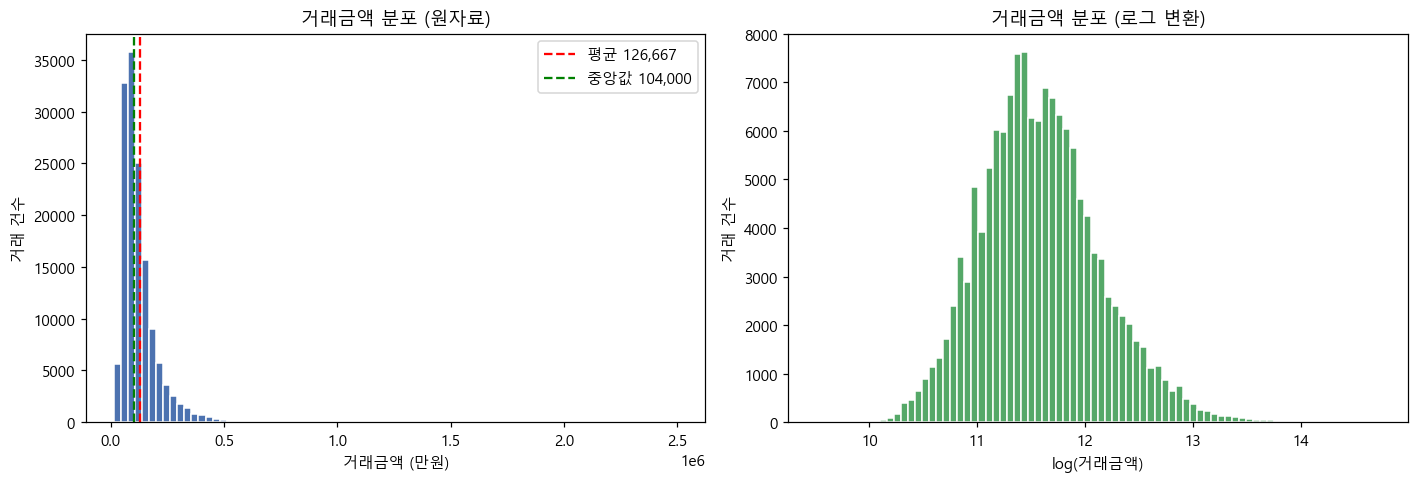

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (좌) 거래금액 원자료 히스토그램
axes[0].hist(df['거래금액_만원'], bins=80, color='#4C72B0', edgecolor='white')
axes[0].set_title('거래금액 분포 (원자료)')
axes[0].set_xlabel('거래금액 (만원)')
axes[0].set_ylabel('거래 건수')
axes[0].axvline(df['거래금액_만원'].mean(), color='red',
                linestyle='--', label=f"평균 {df['거래금액_만원'].mean():,.0f}")
axes[0].axvline(df['거래금액_만원'].median(), color='green',
                linestyle='--', label=f"중앙값 {df['거래금액_만원'].median():,.0f}")
axes[0].legend()

# (우) 로그 변환 거래금액 히스토그램
axes[1].hist(np.log1p(df['거래금액_만원']), bins=80,
             color='#55A868', edgecolor='white')
axes[1].set_title('거래금액 분포 (로그 변환)')
axes[1].set_xlabel('log(거래금액)')
axes[1].set_ylabel('거래 건수')

plt.tight_layout()
plt.show()


**해석.**

좌측 그래프는 거래금액 원자료의 분포로, 평균(빨간 점선)이 중앙값(녹색 점선)보다
오른쪽에 위치하는 전형적인 **우측 꼬리 분포**를 나타낸다. 대다수 거래는 상대적으로
낮은 가격대에 밀집해 있으나, 일부 초고가 거래가 분포의 오른쪽 꼬리를 길게 형성한다.

우측 그래프는 거래금액에 로그 변환을 적용한 결과


## 5. 자치구별 가격 수준 비교

서울 아파트 가격은 입지에 따른 편차가 크다. 자치구를 단위로 평당가를 비교하여 지역별
가격 서열을 파악한다. 면적의 영향을 통제하기 위해 절대 거래금액 대신 **평당가**를
비교 지표로 사용한다.


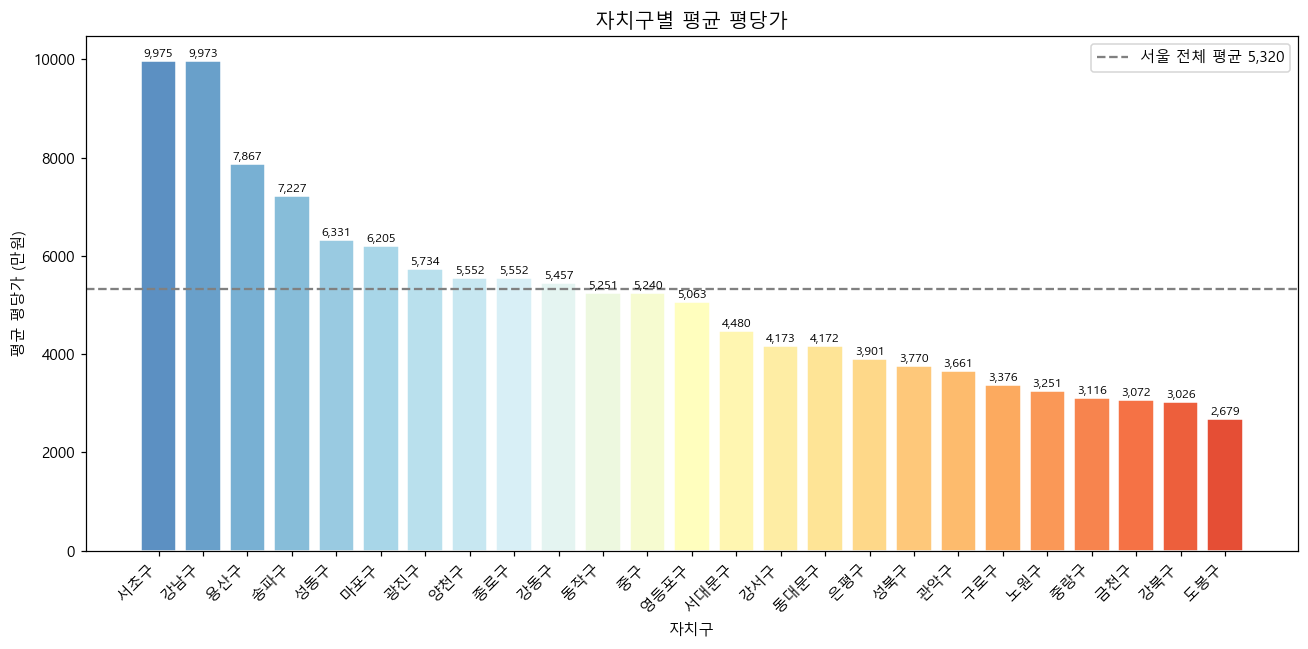

In [9]:
# 자치구별 평균 평당가 (내림차순 정렬)
gu_price = df.groupby('자치구')['평당가_만원'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, len(gu_price)))
bars = ax.bar(gu_price.index, gu_price.values, color=colors, edgecolor='white')
ax.set_title('자치구별 평균 평당가', fontsize=13)
ax.set_xlabel('자치구')
ax.set_ylabel('평균 평당가 (만원)')
ax.axhline(df['평당가_만원'].mean(), color='gray', linestyle='--',
           label=f"서울 전체 평균 {df['평당가_만원'].mean():,.0f}")
plt.xticks(rotation=45, ha='right')
ax.legend()

for b, v in zip(bars, gu_price.values):
    ax.text(b.get_x() + b.get_width()/2, v + 80, f'{v:,.0f}',
            ha='center', fontsize=8)

plt.tight_layout()
plt.show()


**해석.**

자치구별 평균 평당가는 뚜렷한 서열 구조를 보인다. 강남구, 서초구, 송파구 등
이른바 '강남 3구'와 용산구가 서울 전체 평균(회색 점선)을 크게 상회하며 상위권을
형성한다. 반면 외곽 자치구는 평균을 하회하여 하위권에 위치한다. 최상위 자치구와
최하위 자치구 간 평당가 격차는 수 배에 달한다.

이는 **자치구(입지)가 아파트 가격을 설명하는 핵심 변수**임을 명확히 보여준다. 후속
모델링에서 자치구는 반드시 포함되어야 할 범주형 설명변수이며, 전처리 단계에서 적용된
'구별 평균 평당가' 파생 변수 역시 이러한 지역 효과를 수치화한 유효한 입력 변수로
활용될 수 있다.


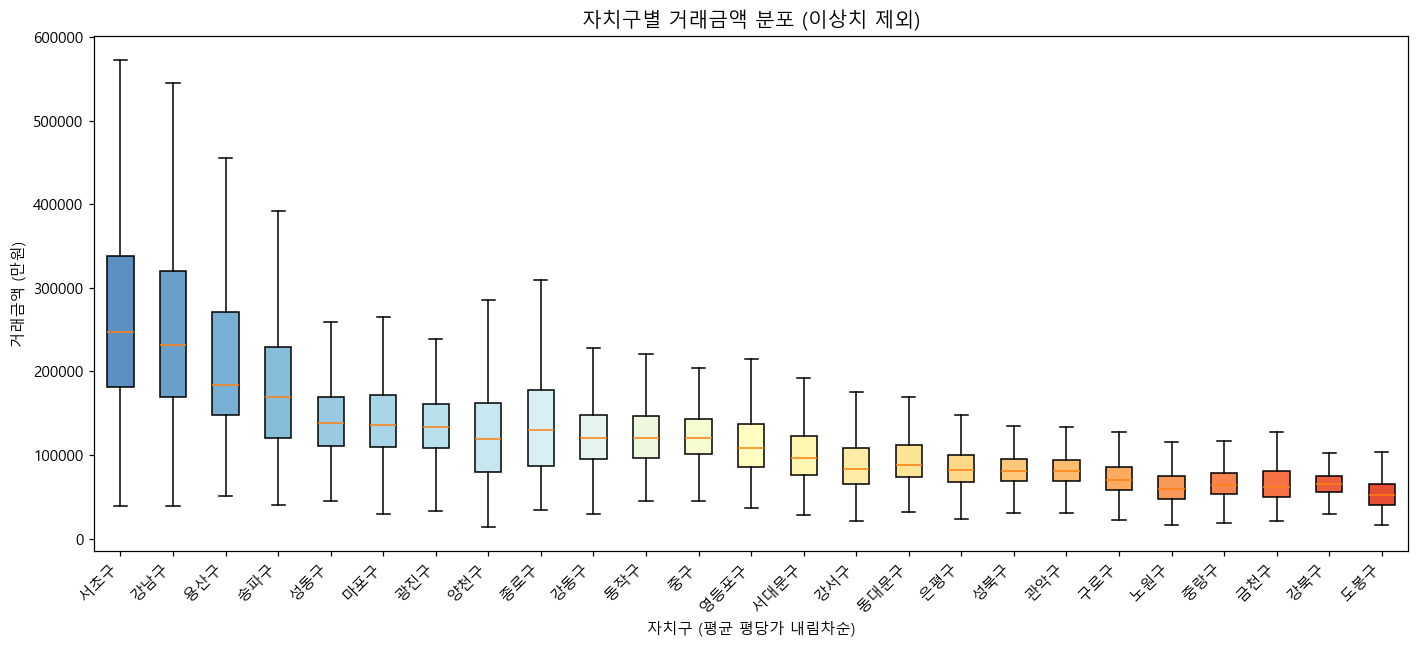

In [10]:
# 자치구별 거래금액 분포 (박스플롯) - 평균 평당가 순으로 정렬
order = gu_price.index.tolist()
box_data = [df.loc[df['자치구'] == g, '거래금액_만원'].values for g in order]

fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot(box_data, labels=order, showfliers=False, patch_artist=True)
for patch, c in zip(bp['boxes'], plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, len(order)))):
    patch.set_facecolor(c)
ax.set_title('자치구별 거래금액 분포 (이상치 제외)', fontsize=13)
ax.set_xlabel('자치구 (평균 평당가 내림차순)')
ax.set_ylabel('거래금액 (만원)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**해석.**

박스플롯은 자치구별 거래금액의 평균뿐 아니라 **분포의 폭(변동성)**까지 함께 보여준다.
상위 자치구는 박스의 위치가 높을 뿐 아니라 박스의 길이(사분위 범위)도 길어, 가격
수준이 높은 동시에 단지·평형 간 가격 편차도 크다는 점을 알 수 있다. 같은 강남구
내에서도 노후 단지와 신축 단지, 소형과 대형 평형 간 거래금액 차이가 상당함을 시사한다.

반면 하위 자치구는 박스가 낮은 위치에 짧게 형성되어, 가격 수준이 낮고 거래금액의
동질성이 높다. 이러한 분포 특성의 차이는 단일 모델이 모든 자치구를 균일한 정확도로
예측하기 어려울 수 있음을 의미하며, 지역별 예측 오차를 별도로 점검할 필요를 제기한다.


## 6. 시간에 따른 거래 추이

2023년 1월부터 2025년 12월까지 월별 거래량과 평균 평당가가 어떻게 변화했는지
살펴본다. 동시에 기준금리와의 관계를 함께 확인한다.


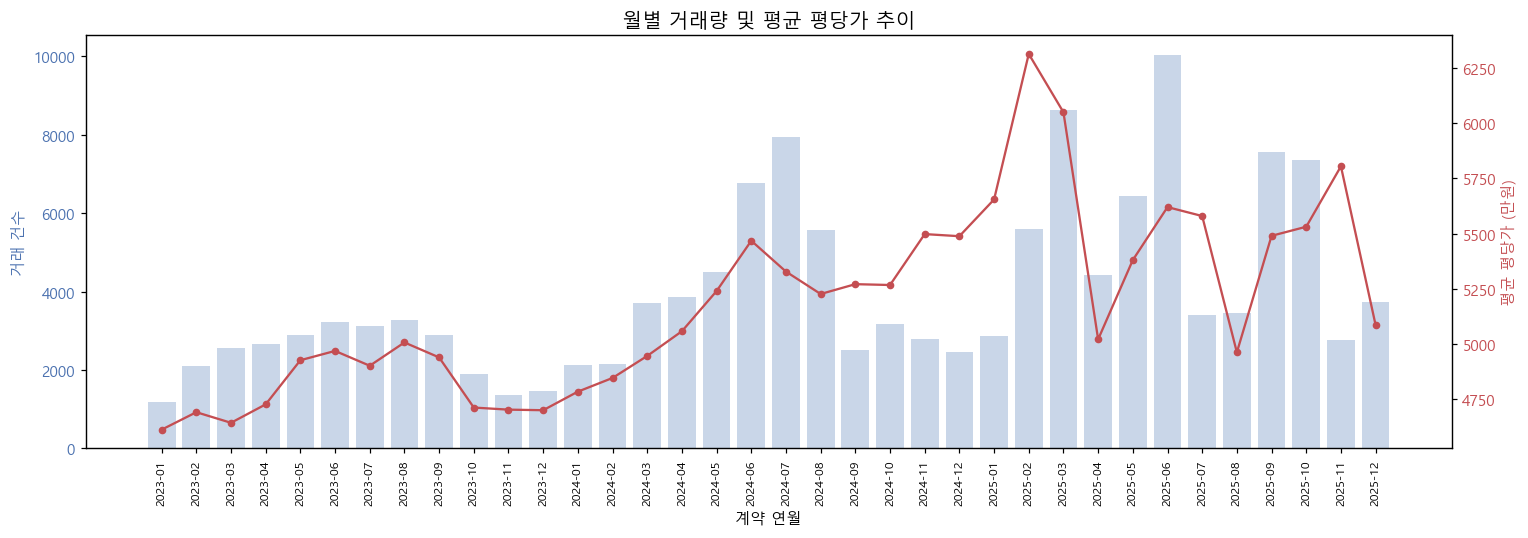

In [11]:
# 월별 거래량 및 월별 평균 평당가
monthly = df.groupby('연월').agg(
    거래건수=('거래금액_만원', 'size'),
    평균평당가=('평당가_만원', 'mean'),
    기준금리=('기준금리', 'first'),
).reset_index().sort_values('연월')

fig, ax1 = plt.subplots(figsize=(14, 5))

# 막대: 월별 거래량
ax1.bar(monthly['연월'], monthly['거래건수'],
        color='#C9D6E8', label='거래 건수')
ax1.set_xlabel('계약 연월')
ax1.set_ylabel('거래 건수', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
plt.xticks(rotation=90, fontsize=8)

# 선: 월별 평균 평당가
ax2 = ax1.twinx()
ax2.plot(monthly['연월'], monthly['평균평당가'],
         color='#C44E52', marker='o', markersize=4, label='평균 평당가')
ax2.set_ylabel('평균 평당가 (만원)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

ax1.set_title('월별 거래량 및 평균 평당가 추이', fontsize=13)
fig.tight_layout()
plt.show()


**해석.**

월별 거래량(막대)과 평균 평당가(선)는 서로 다른 양상으로 움직인다. 거래량은 계절성과
시장 분위기에 따라 월별 변동이 크게 나타나며, 특정 시기에 거래가 집중되거나 위축되는
구간이 관찰된다. 반면 평균 평당가는 거래량만큼 급격하게 변동하지 않고 비교적
완만한 추세를 그린다.

거래량이 적은 달의 평균 평당가는 소수 거래에 의해 좌우되므로 해석에 주의가 필요하다.
또한 거래량과 가격이 항상 같은 방향으로 움직이지는 않으므로, 거래 시점(계약년월)을
모델에 반영할 때는 거래량 효과와 가격 추세 효과를 구분하여 고려해야 한다.


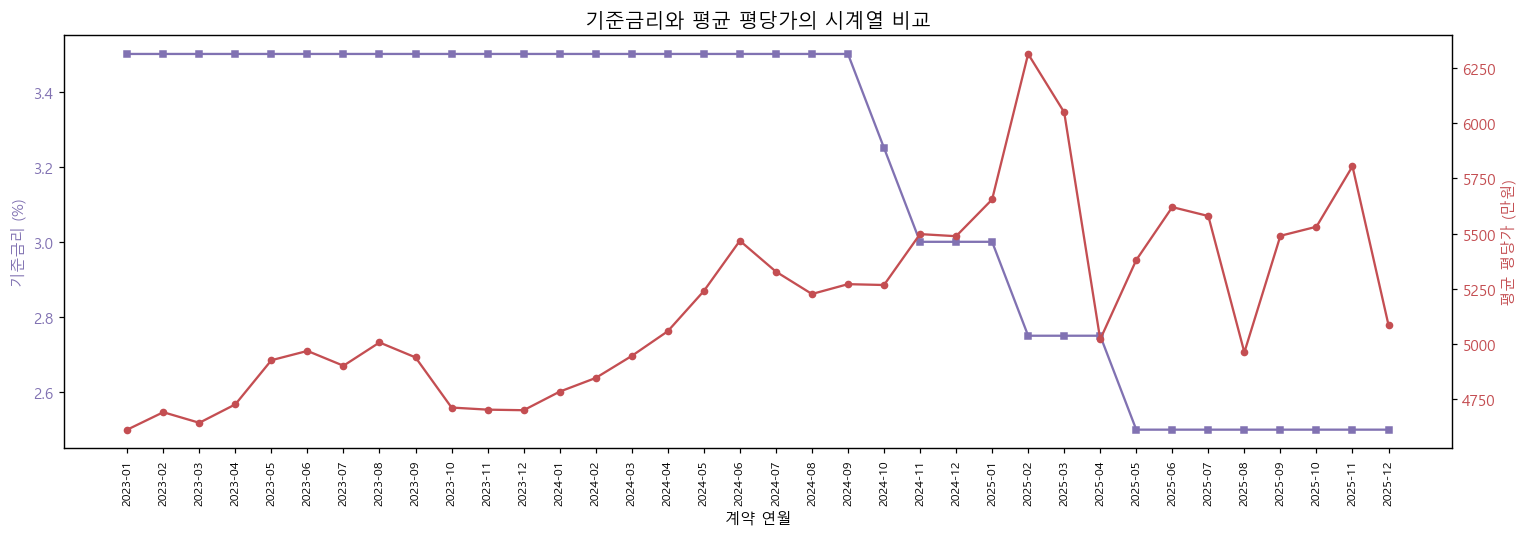

In [12]:
# 기준금리와 평균 평당가의 시계열 동반 추이
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(monthly['연월'], monthly['기준금리'],
         color='#8172B2', marker='s', markersize=4, label='기준금리')
ax1.set_xlabel('계약 연월')
ax1.set_ylabel('기준금리 (%)', color='#8172B2')
ax1.tick_params(axis='y', labelcolor='#8172B2')
plt.xticks(rotation=90, fontsize=8)

ax2 = ax1.twinx()
ax2.plot(monthly['연월'], monthly['평균평당가'],
         color='#C44E52', marker='o', markersize=4, label='평균 평당가')
ax2.set_ylabel('평균 평당가 (만원)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

ax1.set_title('기준금리와 평균 평당가의 시계열 비교', fontsize=13)
fig.tight_layout()
plt.show()


**해석.**

기준금리(보라색)는 2023년~2024년 중반까지 3.50%로 유지되다가 2024년 하반기부터
단계적으로 인하되어 2025년에는 2.50% 수준까지 낮아졌다. 일반적으로 금리 인하는
대출 부담을 완화하여 부동산 수요를 자극하는 요인으로 작용한다.

그래프상 금리 인하 구간에서 평균 평당가(빨간색)의 흐름을 함께 관찰할 수 있으나,
두 변수의 관계를 단정하기에는 분석 기간이 길지 않고 가격에는 금리 외에도 다수의
요인이 작용한다. 또한 이 기간 동안 기준금리는 6개의 값만을 가져 변동 폭이 제한적이다.
따라서 기준금리는 보조적 시장 환경 변수로 활용하되, 단독으로 가격을 설명하는
변수로 과대 해석하지 않도록 유의한다.


## 7. 전용면적과 가격의 관계

작업 지침에서 평수는 가격을 좌우하는 핵심 요인으로 지목되었다. 전용면적과 거래금액의
관계를 산점도로 확인하고, 평형대별 가격 수준을 비교한다.


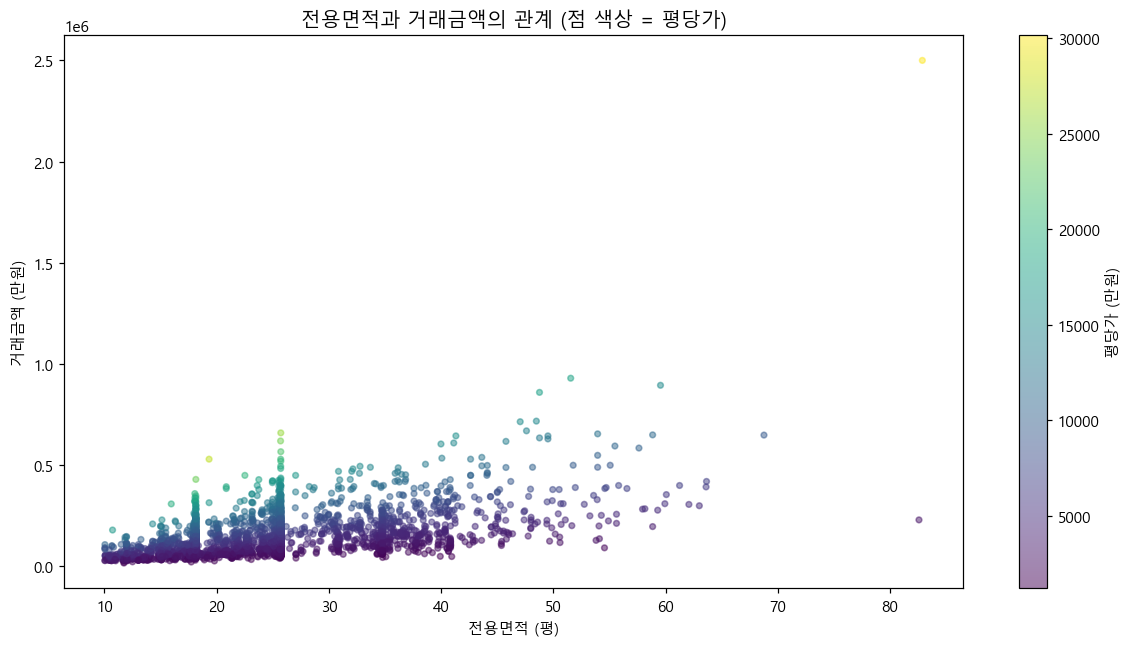

In [13]:
# 전용면적 vs 거래금액 산점도 (표본 추출하여 가독성 확보)
sample = df.sample(n=min(6000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(sample['전용면적_평'], sample['거래금액_만원'],
                c=sample['평당가_만원'], cmap='viridis',
                alpha=0.5, s=14)
ax.set_title('전용면적과 거래금액의 관계 (점 색상 = 평당가)', fontsize=13)
ax.set_xlabel('전용면적 (평)')
ax.set_ylabel('거래금액 (만원)')
cbar = plt.colorbar(sc)
cbar.set_label('평당가 (만원)')
plt.tight_layout()
plt.show()


**해석.**

산점도는 전용면적이 넓을수록 거래금액이 높아지는 뚜렷한 **양(+)의 관계**를 보여준다.
이는 면적이 가격의 1차적 결정 요인이라는 상식과 부합한다.

다만 동일한 면적대에서도 거래금액이 넓게 퍼져 있다는 점이 중요하다. 점의 색상(평당가)을
보면, 같은 면적이라도 평당가가 높은 거래(밝은 색)는 거래금액이 높고, 평당가가 낮은
거래(어두운 색)는 거래금액이 낮다. 즉 **면적은 가격의 크기를 결정하고, 평당가는
입지·연식 등 면적 외 가치를 반영하는 보완적 지표**임을 알 수 있다. 따라서 모델에는
면적과 더불어 평당가에 영향을 주는 입지·연식 변수가 함께 포함되어야 한다.


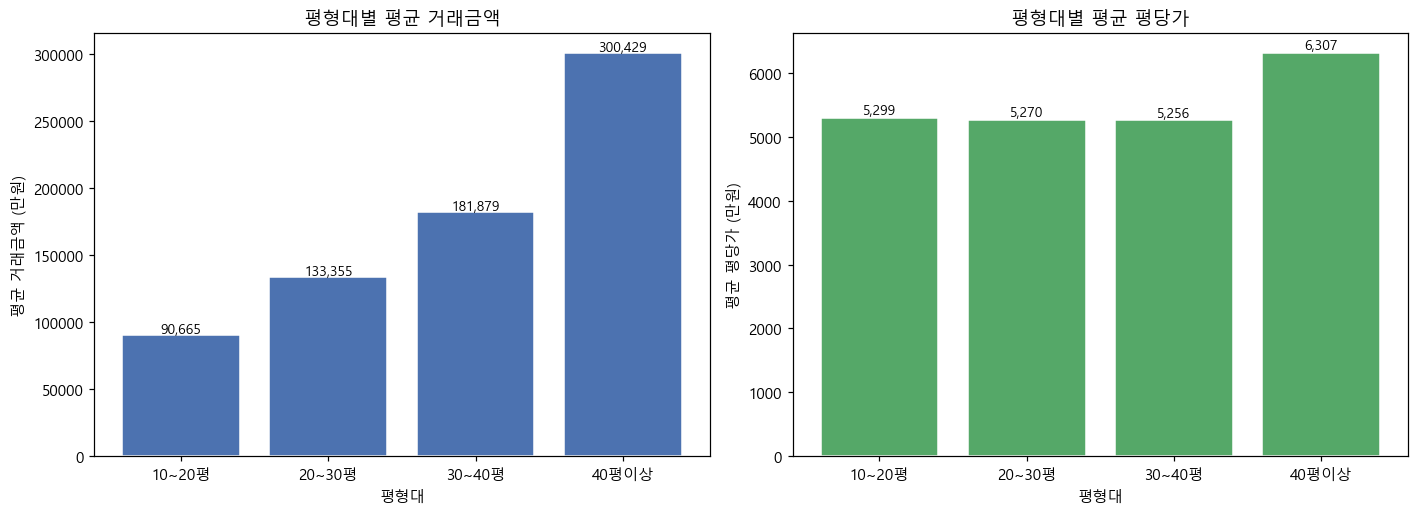

In [14]:
# 평형대별 거래금액 및 평당가 비교
size_order = ['10~20평', '20~30평', '30~40평', '40평이상']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (좌) 평형대별 평균 거래금액
amt = df.groupby('평형대')['거래금액_만원'].mean().reindex(size_order)
axes[0].bar(amt.index, amt.values, color='#4C72B0', edgecolor='white')
axes[0].set_title('평형대별 평균 거래금액')
axes[0].set_xlabel('평형대')
axes[0].set_ylabel('평균 거래금액 (만원)')
for i, v in enumerate(amt.values):
    axes[0].text(i, v + 1500, f'{v:,.0f}', ha='center', fontsize=9)

# (우) 평형대별 평균 평당가
ppy = df.groupby('평형대')['평당가_만원'].mean().reindex(size_order)
axes[1].bar(ppy.index, ppy.values, color='#55A868', edgecolor='white')
axes[1].set_title('평형대별 평균 평당가')
axes[1].set_xlabel('평형대')
axes[1].set_ylabel('평균 평당가 (만원)')
for i, v in enumerate(ppy.values):
    axes[1].text(i, v + 60, f'{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**해석.**

좌측 그래프에서 평균 거래금액은 평형대가 커질수록 일관되게 상승한다. 면적이 넓을수록
총액이 커지는 것은 당연한 결과이다.

주목할 점은 우측의 평당가 그래프이다. 평당가는 거래금액처럼 단순 증가하지 않고, 특정
평형대에서 상대적으로 높게 나타나는 경향을 보인다. 이는 단위 면적당 가치가 평형대에
따라 비선형적으로 달라짐을 의미하며, 중소형 평형의 수요 집중 또는 대형 평형의 입지
프리미엄 등 시장 구조가 반영된 결과로 해석할 수 있다. 따라서 가격 예측 시 면적을
연속형 변수로만 사용하기보다, 평형대 구간 정보를 함께 활용하는 것이 유효하다.


## 8. 건물 연식과 가격의 관계

준공 연도(건물 연식)는 지침에서 지목한 또 다른 핵심 가격 요인이다. 연식 구분별 가격
수준과, 건축년도에 따른 평당가 추이를 확인한다.


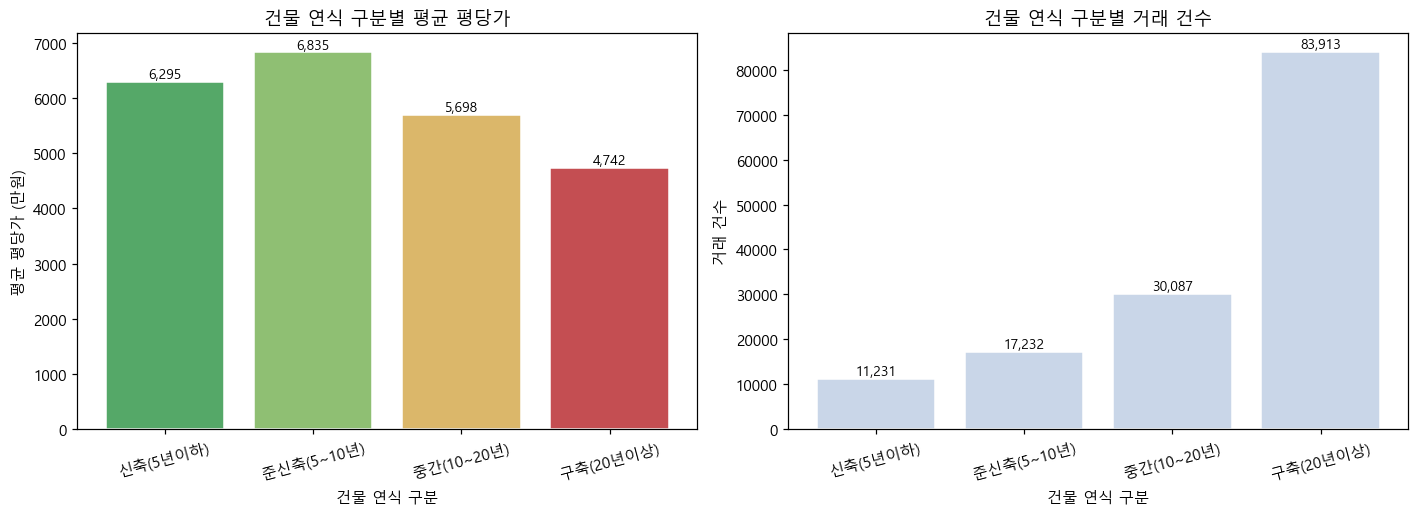

In [15]:
# 건물연식 구분별 평균 평당가
age_order = ['신축(5년이하)', '준신축(5~10년)', '중간(10~20년)', '구축(20년이상)']
age_price = df.groupby('건물연식_구분')['평당가_만원'].mean().reindex(age_order)
age_count = df['건물연식_구분'].value_counts().reindex(age_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (좌) 연식 구분별 평균 평당가
axes[0].bar(age_price.index, age_price.values,
            color=['#55A868', '#8FBF73', '#DBB76A', '#C44E52'],
            edgecolor='white')
axes[0].set_title('건물 연식 구분별 평균 평당가')
axes[0].set_xlabel('건물 연식 구분')
axes[0].set_ylabel('평균 평당가 (만원)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(age_price.values):
    axes[0].text(i, v + 60, f'{v:,.0f}', ha='center', fontsize=9)

# (우) 연식 구분별 거래 건수
axes[1].bar(age_count.index, age_count.values,
            color='#C9D6E8', edgecolor='white')
axes[1].set_title('건물 연식 구분별 거래 건수')
axes[1].set_xlabel('건물 연식 구분')
axes[1].set_ylabel('거래 건수')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(age_count.values):
    axes[1].text(i, v + 800, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**해석.**

좌측 그래프에서 평균 평당가는 신축에서 가장 높고 연식이 오래될수록 낮아지는 경향이
관찰된다. 이는 신축 아파트의 우수한 설비·구조·커뮤니티 시설이 가격 프리미엄으로
반영된 결과이다.

다만 구축(20년 이상) 구분의 평당가가 단순히 가장 낮다고 단정해서는 안 된다. 강남권
재건축 대상 노후 단지처럼, 입지 가치와 재건축 기대가 결합되어 구축임에도 높은 가격을
형성하는 사례가 존재하기 때문이다. 우측 그래프에서 보듯 거래 건수 자체는 구축 구분이
가장 많아, 서울 주택 재고의 상당 부분이 노후 단지로 구성되어 있음을 알 수 있다.
연식 효과는 입지 효과와 교호작용하므로, 모델에서 연식과 입지를 함께 고려해야 한다.


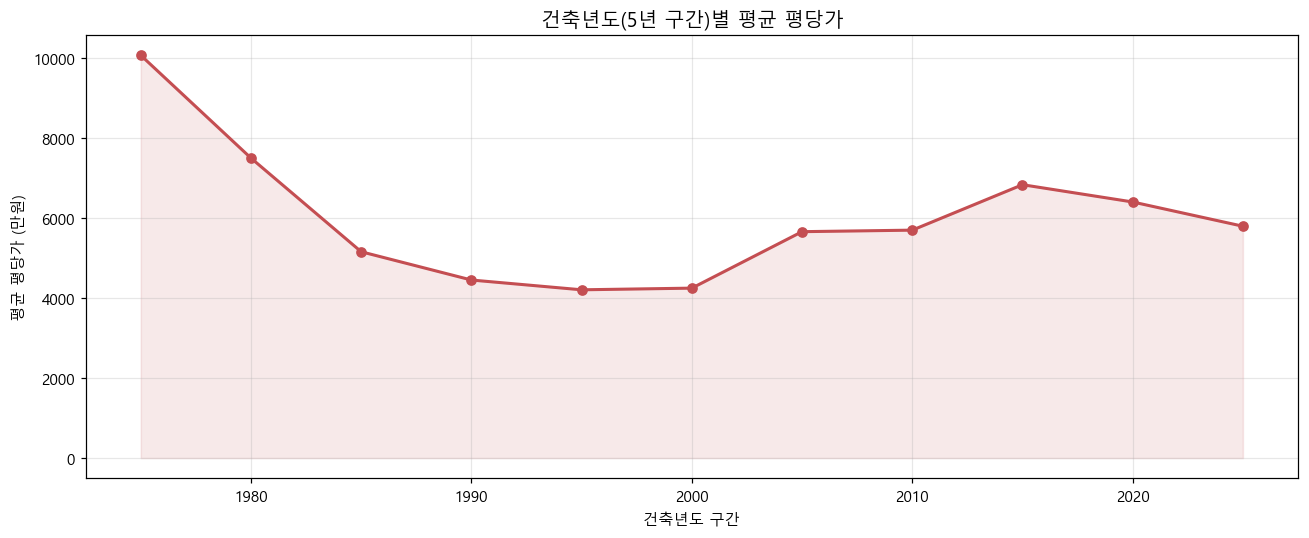

In [16]:
# 건축년도별 평균 평당가 추이 (5년 단위 구간)
df_year = df[df['건축년도'] >= 1975].copy()
df_year['건축년도_구간'] = (df_year['건축년도'] // 5) * 5
yr_trend = df_year.groupby('건축년도_구간')['평당가_만원'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yr_trend.index, yr_trend.values,
        color='#C44E52', marker='o', markersize=6, linewidth=2)
ax.fill_between(yr_trend.index, yr_trend.values, alpha=0.12, color='#C44E52')
ax.set_title('건축년도(5년 구간)별 평균 평당가', fontsize=13)
ax.set_xlabel('건축년도 구간')
ax.set_ylabel('평균 평당가 (만원)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**해석.**

건축년도를 5년 단위로 구간화하여 평균 평당가를 살펴보면, 연식과 가격의 관계가 단순한
직선이 아니라는 점이 드러난다. 일반적으로 최근에 지어진 단지일수록 평당가가 높지만,
아주 오래된 연식 구간에서도 평당가가 다시 상승하는 구간이 관찰될 수 있다. 이는
재건축 기대가 반영된 노후 우량 단지의 영향으로 해석된다.

이러한 **비선형 관계**는 중요한 시사점을 제공한다. 건축년도 또는 건물 연식을 단순
선형 변수로 투입하는 회귀 모델은 이 패턴을 충분히 포착하지 못할 수 있다. 따라서
연식의 비선형성을 다룰 수 있는 모델(예: 트리 기반 모델)을 고려하거나, 연식 구간을
범주형으로 변환하여 사용하는 전처리 전략이 유효하다.


## 9. 지하철 접근성과 가격의 관계

지침에서 지하철역과 아파트 간 거리는 가격의 핵심 요인으로 명시되었다. 최근접 역까지의
거리가 가격에 미치는 영향을 구간별로 분석한다.


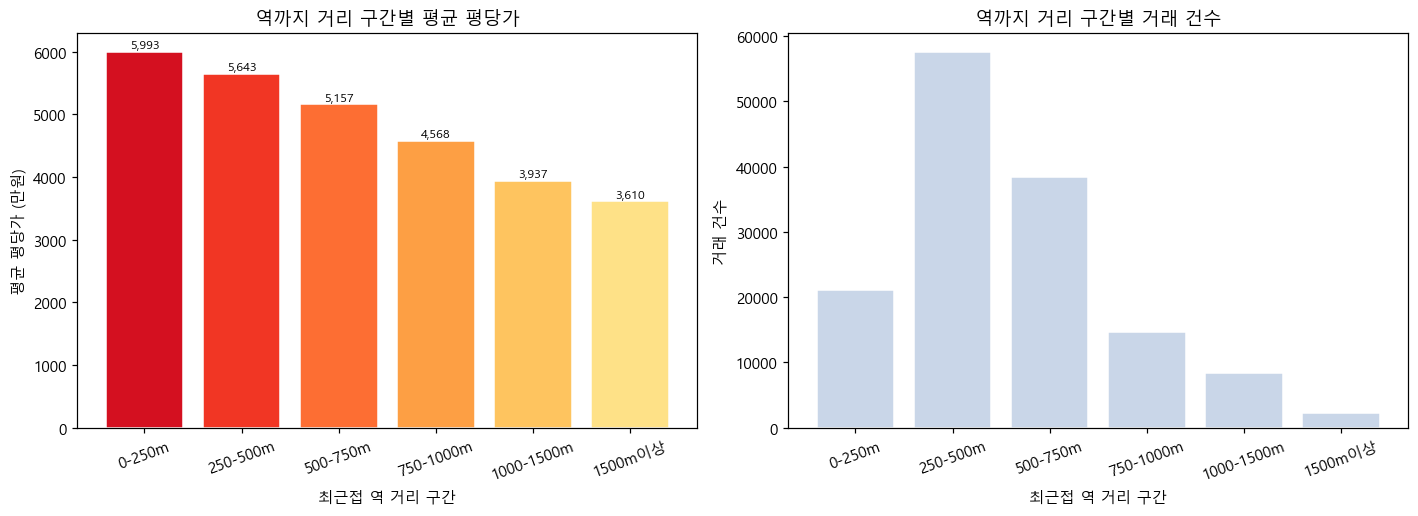

In [17]:
# 역 거리 구간화 후 구간별 평균 평당가
bins = [0, 250, 500, 750, 1000, 1500, df['최근접_역_거리(m)'].max() + 1]
labels = ['0-250m', '250-500m', '500-750m',
          '750-1000m', '1000-1500m', '1500m이상']
df['역거리_구간'] = pd.cut(df['최근접_역_거리(m)'], bins=bins, labels=labels)

dist_price = df.groupby('역거리_구간')['평당가_만원'].mean()
dist_count = df['역거리_구간'].value_counts().reindex(labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].bar(dist_price.index, dist_price.values,
            color=plt.cm.YlOrRd_r(np.linspace(0.2, 0.8, len(dist_price))),
            edgecolor='white')
axes[0].set_title('역까지 거리 구간별 평균 평당가')
axes[0].set_xlabel('최근접 역 거리 구간')
axes[0].set_ylabel('평균 평당가 (만원)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(dist_price.values):
    axes[0].text(i, v + 60, f'{v:,.0f}', ha='center', fontsize=8)

axes[1].bar(dist_count.index, dist_count.values,
            color='#C9D6E8', edgecolor='white')
axes[1].set_title('역까지 거리 구간별 거래 건수')
axes[1].set_xlabel('최근접 역 거리 구간')
axes[1].set_ylabel('거래 건수')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


**해석.**

좌측 그래프는 역까지의 거리가 멀어질수록 평균 평당가가 낮아지는 경향을 보여준다.
역과 가까운 구간(0~250m)의 평당가가 가장 높고, 거리가 멀어질수록 점진적으로 하락하는
패턴은 **역세권 프리미엄**이 실제로 가격에 반영되고 있음을 뒷받침한다.

다만 구간 간 가격 차이의 폭은 자치구 간 격차에 비하면 상대적으로 완만하다. 이는 역
접근성이 가격에 영향을 주는 요인인 것은 분명하나, 그 단독 효과는 자치구·면적·연식
등 다른 요인에 비해 크지 않을 수 있음을 시사한다. 우측 그래프에서 보듯 거래의 다수가
1,000m 이내 구간에 분포하여, 서울 아파트 대부분이 도보권 역세권에 위치한다는 점도
거리 변수의 변별력을 일부 제한하는 요인이다.


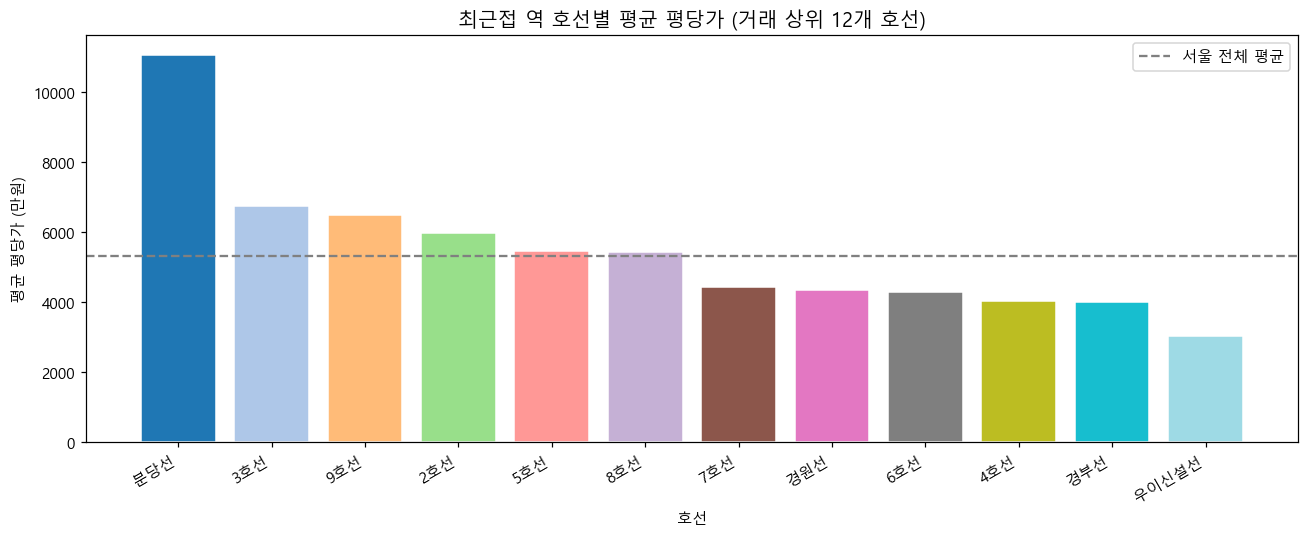

In [18]:
# 호선별 평균 평당가 (거래 건수 상위 12개 호선)
top_lines = df['최근접_역_호선'].value_counts().head(12).index
line_price = (df[df['최근접_역_호선'].isin(top_lines)]
              .groupby('최근접_역_호선')['평당가_만원']
              .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(line_price.index, line_price.values,
       color=plt.cm.tab20(np.linspace(0, 1, len(line_price))),
       edgecolor='white')
ax.set_title('최근접 역 호선별 평균 평당가 (거래 상위 12개 호선)', fontsize=13)
ax.set_xlabel('호선')
ax.set_ylabel('평균 평당가 (만원)')
ax.axhline(df['평당가_만원'].mean(), color='gray', linestyle='--',
           label='서울 전체 평균')
plt.xticks(rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


**해석.**

호선별 평균 평당가에는 뚜렷한 차이가 존재한다. 다만 이 차이는 노선 자체의 효과라기보다,
각 노선이 통과하는 **지역의 입지 가치가 반영된 결과**로 해석하는 것이 타당하다. 예를
들어 강남권을 관통하는 노선은 평당가가 높게 나타나는데, 이는 노선의 우수성보다 해당
노선 주변 지역의 가격 수준이 높기 때문이다.

따라서 호선 변수는 자치구 변수와 정보가 상당 부분 중복(다중공선성)될 가능성이 있다.
모델링 시 호선을 입력 변수로 사용할 경우, 자치구 변수와의 중복을 고려하여 둘 중 하나를
선택하거나 변수 중요도를 신중히 검토할 필요가 있다.


## 10. 교육 환경과 가격의 관계

학교 접근성 또한 주거 입지 평가의 주요 요소이다. 초·중·고등학교까지의 거리와 평당가의
관계를 확인한다.


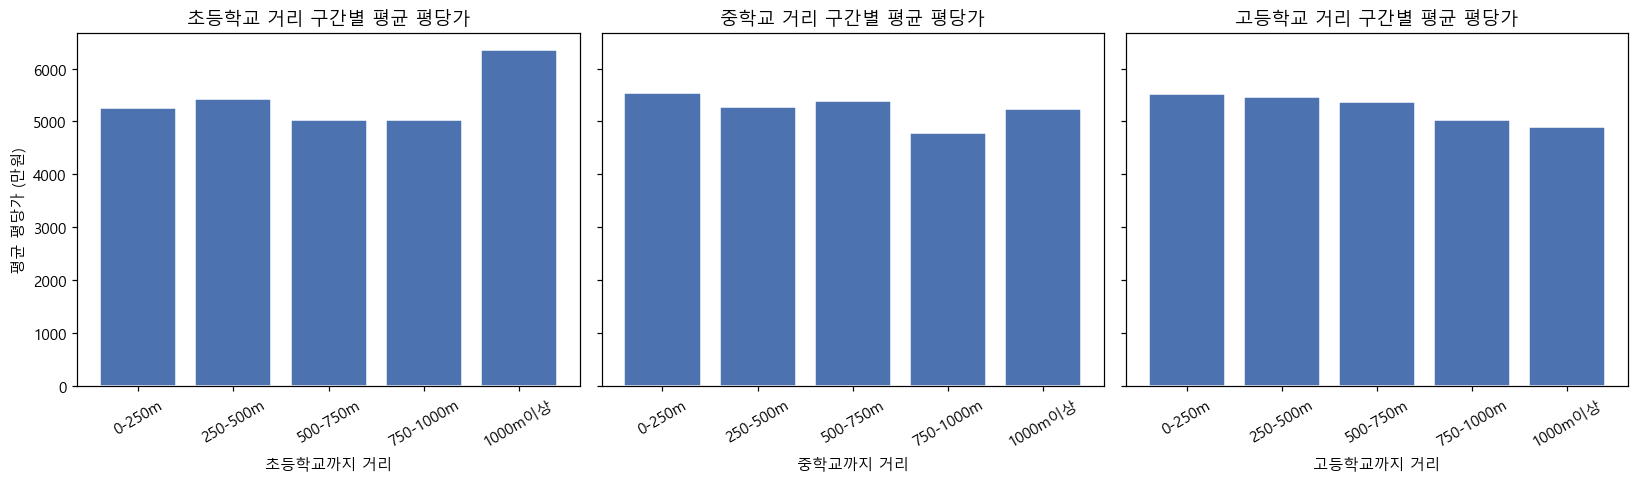

In [19]:
# 학교 거리 구간별 평균 평당가
school_cols = {
    '최근접_초등학교_거리(m)': '초등학교',
    '최근접_중학교_거리(m)': '중학교',
    '최근접_고등학교_거리(m)': '고등학교',
}
sch_bins = [0, 250, 500, 750, 1000, 5000]
sch_labels = ['0-250m', '250-500m', '500-750m', '750-1000m', '1000m이상']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (col, name) in zip(axes, school_cols.items()):
    grp = pd.cut(df[col], bins=sch_bins, labels=sch_labels)
    means = df.groupby(grp)['평당가_만원'].mean()
    ax.bar(means.index, means.values, color='#4C72B0', edgecolor='white')
    ax.set_title(f'{name} 거리 구간별 평균 평당가')
    ax.set_xlabel(f'{name}까지 거리')
    ax.tick_params(axis='x', rotation=30)
axes[0].set_ylabel('평균 평당가 (만원)')
plt.tight_layout()
plt.show()


**해석.**

세 개의 그래프는 초·중·고등학교까지의 거리 구간별 평균 평당가를 나타낸다. 학교가
가까운 구간에서 평당가가 다소 높게 형성되는 경향이 일부 관찰되나, 거리 구간 간
가격 차이는 자치구나 면적 변수에 비해 작은 편이다.

학교 접근성의 가격 효과가 시각적으로 약하게 나타나는 이유는, 서울 시내 대부분의
아파트가 이미 도보권 내에 학교를 두고 있어 거리 변수의 변별력이 크지 않기 때문이다.
또한 학군의 가치는 단순한 물리적 거리보다 특정 학교의 학업 성취도나 배정 가능 여부에
좌우되는데, 본 데이터의 거리 변수는 이러한 정성적 학군 가치를 직접 담지 못한다.
따라서 학교 거리 변수는 보조적 입력 변수로 활용하되 효과를 과대 해석하지 않는다.


## 11. 수치형 변수 간 상관관계

주요 수치형 변수 간 상관계수를 산출하여, 가격과의 관계 및 변수 간 중복성을 종합적으로
점검한다. 이는 모델 입력 변수 선정의 핵심 근거가 된다.


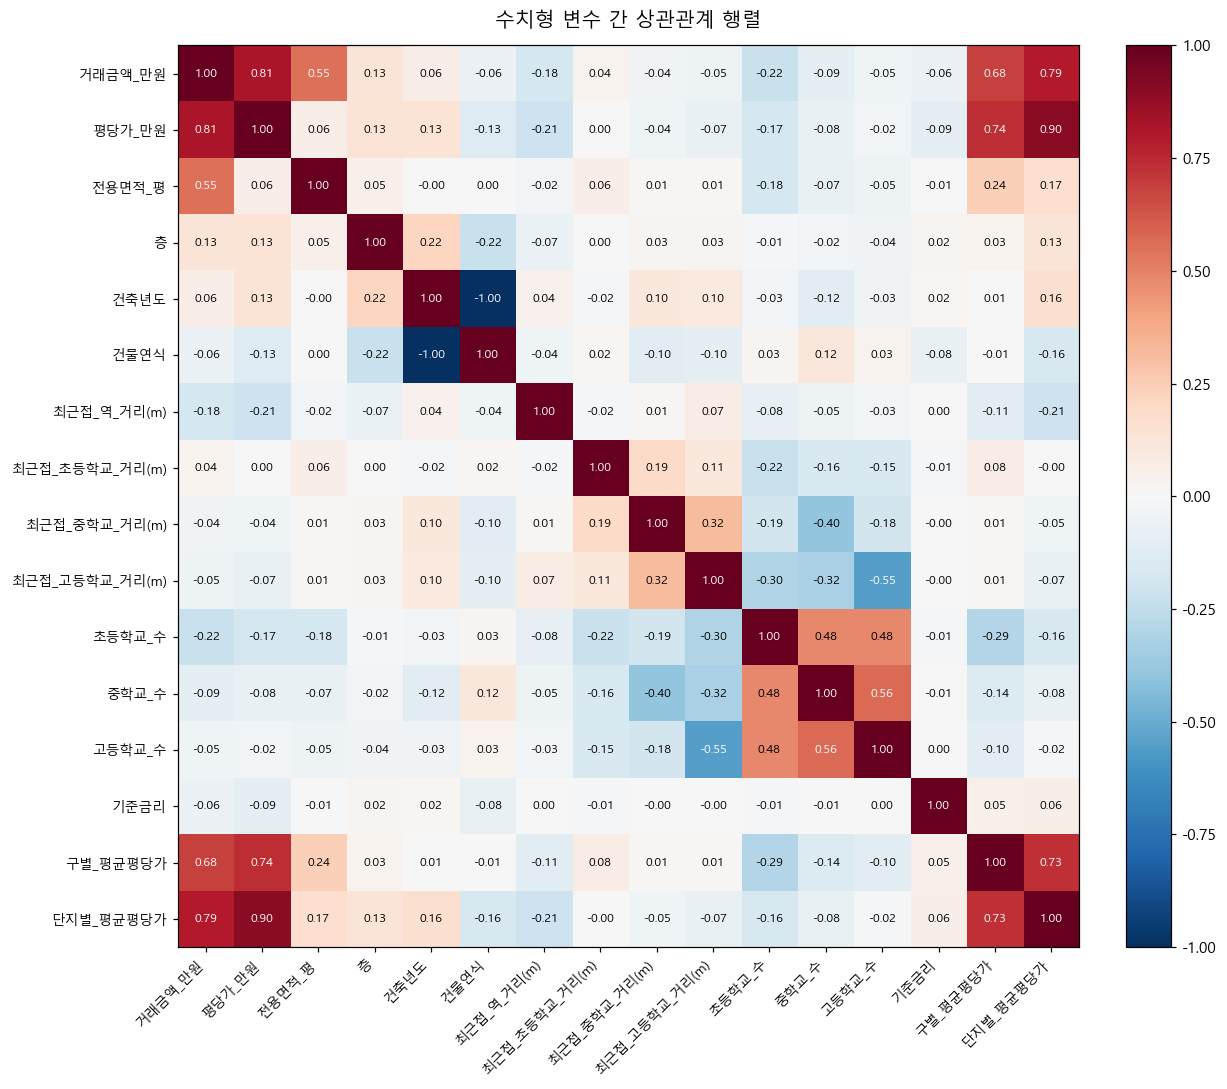

In [20]:
# 상관관계 분석 대상 변수
corr_cols = ['거래금액_만원', '평당가_만원', '전용면적_평', '층',
             '건축년도', '건물연식', '최근접_역_거리(m)',
             '최근접_초등학교_거리(m)', '최근접_중학교_거리(m)',
             '최근접_고등학교_거리(m)',
             '초등학교_수', '중학교_수', '고등학교_수', '기준금리',
             '구별_평균평당가', '단지별_평균평당가']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# 각 셀에 상관계수 표시
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if abs(val) > 0.5 else 'black', fontsize=8)

plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('수치형 변수 간 상관관계 행렬', fontsize=13, pad=12)
plt.tight_layout()
plt.show()


**해석.**

상관관계 행렬에서 거래금액과 다른 변수들의 관계를 중심으로 다음을 확인할 수 있다.

- **거래금액과 전용면적**은 강한 양의 상관을 보인다. 면적이 거래금액의 가장 직접적인
  결정 요인이라는 앞선 분석과 일치한다.
- **거래금액과 단지별·구별 평균 평당가** 역시 양의 상관을 보인다. 전처리 단계에서
  생성된 이들 집계 변수가 입지 가치를 효과적으로 요약하고 있음을 의미하며, 모델의
  유력한 입력 변수가 될 수 있다.
- **건축년도와 건물연식**은 거의 완전한 음의 상관(-1에 근접)을 보인다. 두 변수는
  사실상 동일한 정보를 담고 있으므로, **모델에는 둘 중 하나만 사용**해야 한다. 동시
  투입 시 다중공선성 문제가 발생한다.
- **역·학교까지의 거리 변수**는 거래금액과 약한 음의 상관을 보인다. 거리가 가까울수록
  가격이 높아지는 방향성은 맞으나, 그 강도는 면적·입지 변수에 비해 약하다.

이 결과는 모델 입력 변수 선정의 명확한 지침을 제공한다. 즉, 건축년도와 건물연식 중
하나만 선택하고, 면적과 입지 집계 변수를 핵심 변수로 삼되, 거리 변수는 보조 변수로
활용하는 전략이 합리적이다.


### 11-2. 거래금액과 각 변수의 상관계수 정렬 및 관계 강도 정리

앞의 상관 행렬은 모든 변수 쌍의 관계를 보여주나, 종속변수인 **거래금액**과 각 설명변수
간의 관계만을 따로 추출하여 상관계수의 절대값 크기 순으로 정렬하면 변수의 중요도를
한눈에 비교할 수 있다. 또한 상관계수의 절대값을 아래 기준에 따라 관계 강도 등급으로
분류하여 해석을 표준화한다.



In [21]:
# 거래금액과 각 수치형 변수의 상관계수 추출 및 정렬
target = '거래금액_만원'

# 거래금액 자신을 제외하고, 상관계수 절대값 기준 내림차순 정렬
corr_target = (corr[target]
               .drop(target)
               .sort_values(key=lambda s: s.abs(), ascending=False))


# 상관계수 절대값을 관계 강도 등급으로 변환하는 함수
def classify_strength(r):
    a = abs(r)
    if a >= 0.7:
        return '매우 강함'
    elif a >= 0.4:
        return '강함'
    elif a >= 0.2:
        return '뚜렷함'
    elif a >= 0.1:
        return '약함'
    else:
        return '미미함'


# 정렬 결과를 표 형태로 정리
corr_summary = pd.DataFrame({
    '변수': corr_target.index,
    '상관계수': corr_target.values.round(3),
    '상관계수_절대값': np.abs(corr_target.values).round(3),
    '관계_방향': np.where(corr_target.values >= 0, '양(+)', '음(-)'),
    '관계_강도': [classify_strength(r) for r in corr_target.values],
}).reset_index(drop=True)
corr_summary.index = corr_summary.index + 1   # 순위를 1부터 표시

corr_summary


,변수,상관계수,상관계수_절대값,관계_방향,관계_강도
1,평당가_만원,0.814,0.814,양(+),매우 강함
2,단지별_평균평당가,0.790,0.790,양(+),매우 강함
3,구별_평균평당가,0.681,0.681,양(+),강함
4,전용면적_평,0.552,0.552,양(+),강함
5,초등학교_수,-0.222,0.222,음(-),뚜렷함
6,최근접_역_거리(m),-0.176,0.176,음(-),약함
7,층,0.126,0.126,양(+),약함
8,중학교_수,-0.088,0.088,음(-),미미함
9,건축년도,0.064,0.064,양(+),미미함
10,기준금리,-0.062,0.062,음(-),미미함


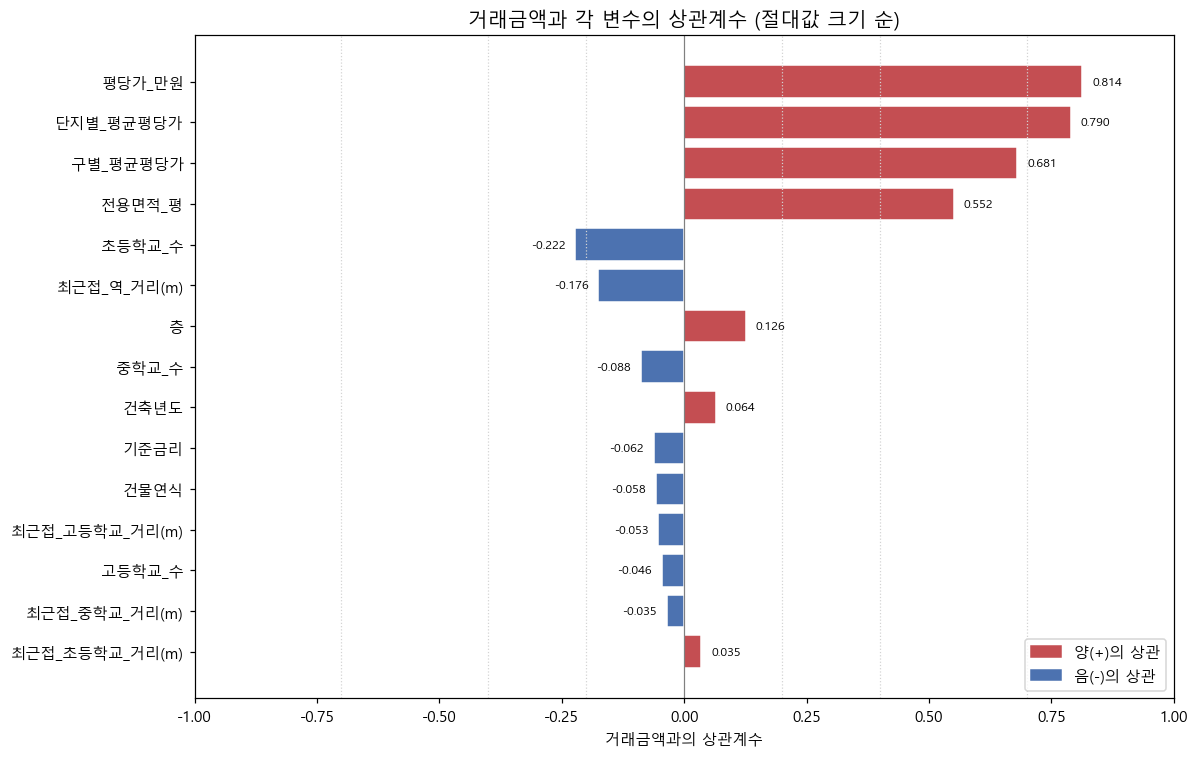

In [22]:
# 거래금액과의 상관계수를 가로 막대그래프로 시각화
fig, ax = plt.subplots(figsize=(11, 7))

# 양(+)/음(-) 방향에 따라 막대 색상 구분
bar_colors = ['#C44E52' if v >= 0 else '#4C72B0' for v in corr_target.values]
y_pos = np.arange(len(corr_target))[::-1]   # 상위 변수가 위쪽에 오도록 배치
ax.barh(y_pos, corr_target.values, color=bar_colors, edgecolor='white')

ax.set_yticks(y_pos)
ax.set_yticklabels(corr_target.index)
ax.set_xlabel('거래금액과의 상관계수')
ax.set_title('거래금액과 각 변수의 상관계수 (절대값 크기 순)', fontsize=13)
ax.axvline(0, color='gray', linewidth=0.8)

# 관계 강도 등급 경계선 표시
for x in [0.2, 0.4, 0.7, -0.2, -0.4, -0.7]:
    ax.axvline(x, color='lightgray', linestyle=':', linewidth=0.8)

# 각 막대 끝에 상관계수 값 표기
for y, v in zip(y_pos, corr_target.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), y, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)

ax.set_xlim(-1, 1)

# 범례
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C44E52', label='양(+)의 상관'),
                   Patch(color='#4C72B0', label='음(-)의 상관')],
          loc='lower right')

plt.tight_layout()
plt.show()


#### 거래금액과 각 변수의 상관계수 정리표

위 코드의 실행 결과를 표로 정리하면 다음과 같다. 거래금액과의 상관계수 절대값이 큰
순서대로 나열하였으며, 관계의 방향과 강도 등급을 함께 제시한다.

| 순위 | 변수 | 상관계수 | 관계 방향 | 관계 강도 |
|:---:|---|:---:|:---:|:---:|
| 1 | 평당가_만원 | 0.814 | 양(+) | 매우 강함 |
| 2 | 단지별_평균평당가 | 0.790 | 양(+) | 매우 강함 |
| 3 | 구별_평균평당가 | 0.681 | 양(+) | 강함 |
| 4 | 전용면적_평 | 0.552 | 양(+) | 강함 |
| 5 | 초등학교_수 | -0.222 | 음(-) | 뚜렷함 |
| 6 | 최근접_역_거리(m) | -0.176 | 음(-) | 약함 |
| 7 | 층 | 0.126 | 양(+) | 약함 |
| 8 | 중학교_수 | -0.088 | 음(-) | 미미함 |
| 9 | 건축년도 | 0.064 | 양(+) | 미미함 |
| 10 | 기준금리 | -0.062 | 음(-) | 미미함 |
| 11 | 건물연식 | -0.058 | 음(-) | 미미함 |
| 12 | 최근접_고등학교_거리(m) | -0.053 | 음(-) | 미미함 |
| 13 | 고등학교_수 | -0.046 | 음(-) | 미미함 |
| 14 | 최근접_중학교_거리(m) | -0.035 | 음(-) | 미미함 |
| 15 | 최근접_초등학교_거리(m) | 0.035 | 양(+) | 미미함 |

**관계 강도별 변수 분류 요약**

| 관계 강도 | 해당 변수 | 거래금액과의 관계 |
|:---:|---|---|
| 매우 강함 | 평당가_만원, 단지별_평균평당가 | 거래금액과 거의 직결되는 가격성 지표 |
| 강함 | 구별_평균평당가, 전용면적_평 | 입지·면적 — 가격을 설명하는 핵심 요인 |
| 뚜렷함 | 초등학교_수 | 주변 학교 밀집도, 보조적 입지 지표 |
| 약함 | 최근접_역_거리(m), 층 | 방향성은 뚜렷하나 단독 설명력은 제한적 |
| 미미함 | 건축년도, 건물연식, 기준금리, 중·고교 수, 학교 거리 등 | 선형 상관 약함, 비선형 효과는 별도 검토 필요 |

**해석.**

위 표는 거래금액과 각 변수의 상관계수를 절대값 크기 순으로 정렬한 결과이며, 관계의
강도와 방향을 함께 정리한 것이다.

**가. 매우 강한 관계**

- **평당가, 단지별 평균 평당가**가 거래금액과 매우 강한 양(+)의 상관을 보인다. 평당가는
  거래금액을 면적으로 나눈 값에 가깝고, 단지별 평균 평당가는 해당 단지의 가격 수준을
  직접 요약한 파생 변수이므로 거래금액과 밀접하게 연동되는 것은 당연한 결과이다. 다만
  평당가는 거래금액으로부터 산출된 변수이므로, 가격 예측 모델의 입력 변수로 사용할
  경우 정보 누설(data leakage)에 해당할 수 있어 주의가 필요하다.

**나. 강한 관계**

- **구별 평균 평당가, 전용면적**이 거래금액과 강한 양(+)의 상관을 보인다. 입지(구별
  가격 수준)와 면적이 거래금액을 설명하는 핵심 요인임을 수치로 재확인한다. 이 두 변수는
  거래금액으로부터 직접 파생되지 않으므로, 모델의 핵심 입력 변수로 적합하다.

**다. 뚜렷함·약함 관계**

- 학교 수, 최근접 역 거리, 층 등이 이 구간에 속한다. 가격에 영향을 주는 방향성은
  확인되나(역·학교가 가까울수록, 층이 높을수록 가격이 높아지는 경향), 그 단독 설명력은
  면적·입지 변수에 비해 제한적이다. 보조 입력 변수로 활용하는 것이 적절하다.

**라. 미미한 관계**

- 건축년도, 건물연식, 기준금리, 일부 학교 거리 변수가 이 구간에 속한다. 거래금액과의
  선형 상관이 약하다는 의미이며, 변수가 무의미하다는 뜻은 아니다. 특히 건물 연식은
  앞선 8장에서 가격과 **비선형 관계**를 보였으므로, 선형 상관계수만으로는 그 효과가
  과소평가된다. 이러한 변수는 비선형 패턴을 포착할 수 있는 트리 기반 모델에서 유효한
  기여를 할 수 있다.

**종합.** 거래금액과의 선형 관계 강도는 평당가 계열 > 입지·면적 변수 > 접근성 변수 >
연식·금리 변수 순으로 나타난다. 모델 입력 변수는 구별 평균 평당가, 단지별 평균 평당가,
전용면적을 중심으로 구성하되, 선형 상관이 약한 연식 변수는 비선형 모델을 통해 그
효과를 반영하는 전략이 바람직하다.


### 11-3. 상위 지배 변수 제외 후 거래금액 상관계수 재분석

11-2장의 막대그래프에서 `평당가_만원`, `단지별_평균평당가`, `구별_평균평당가`,
`전용면적_평` 네 변수는 거래금액과 강하거나 매우 강한 상관을 보여 그래프의 척도를
사실상 지배한다. 그 결과 나머지 변수들의 상관계수가 0 부근에 좁게 몰려, 변수 간
상대적 영향력의 차이를 시각적으로 식별하기 어렵다.

이 네 변수는 분석적으로도 별도 취급이 필요하다. 평당가는 거래금액에서 직접 파생된
변수이고, 단지별·구별 평균 평당가 역시 거래금액을 집계한 변수이며, 전용면적은 거래
금액과의 강한 관계가 이미 7장에서 충분히 확인되었다. 따라서 이 네 변수를 제외하고
**나머지 변수만으로 상관계수를 다시 정렬**하면, 입지·환경·시점 등 보조 변수들이
거래금액에 미치는 영향의 상대적 크기를 한층 명확하게 비교할 수 있다.


In [23]:
# 11-2장에서 그래프 척도를 지배한 상위 4개 변수를 제외
exclude_cols = ['평당가_만원', '단지별_평균평당가', '구별_평균평당가', '전용면적_평']

# 거래금액 자신과 제외 변수를 함께 제거한 뒤 절대값 기준 내림차순 정렬
corr_target_sub = (corr[target]
                   .drop([target] + exclude_cols)
                   .sort_values(key=lambda s: s.abs(), ascending=False))

# 관계 강도 등급은 11-2장에서 정의한 classify_strength 함수를 재사용
corr_summary_sub = pd.DataFrame({
    '변수': corr_target_sub.index,
    '상관계수': corr_target_sub.values.round(3),
    '상관계수_절대값': np.abs(corr_target_sub.values).round(3),
    '관계_방향': np.where(corr_target_sub.values >= 0, '양(+)', '음(-)'),
    '관계_강도': [classify_strength(r) for r in corr_target_sub.values],
}).reset_index(drop=True)
corr_summary_sub.index = corr_summary_sub.index + 1

print(f'제외 변수: {exclude_cols}')
print(f'분석 대상 변수: {len(corr_summary_sub)}개')
corr_summary_sub


제외 변수: ['평당가_만원', '단지별_평균평당가', '구별_평균평당가', '전용면적_평']
분석 대상 변수: 11개


,변수,상관계수,상관계수_절대값,관계_방향,관계_강도
1,초등학교_수,-0.222,0.222,음(-),뚜렷함
2,최근접_역_거리(m),-0.176,0.176,음(-),약함
3,층,0.126,0.126,양(+),약함
4,중학교_수,-0.088,0.088,음(-),미미함
5,건축년도,0.064,0.064,양(+),미미함
6,기준금리,-0.062,0.062,음(-),미미함
7,건물연식,-0.058,0.058,음(-),미미함
8,최근접_고등학교_거리(m),-0.053,0.053,음(-),미미함
9,고등학교_수,-0.046,0.046,음(-),미미함
10,최근접_중학교_거리(m),-0.035,0.035,음(-),미미함


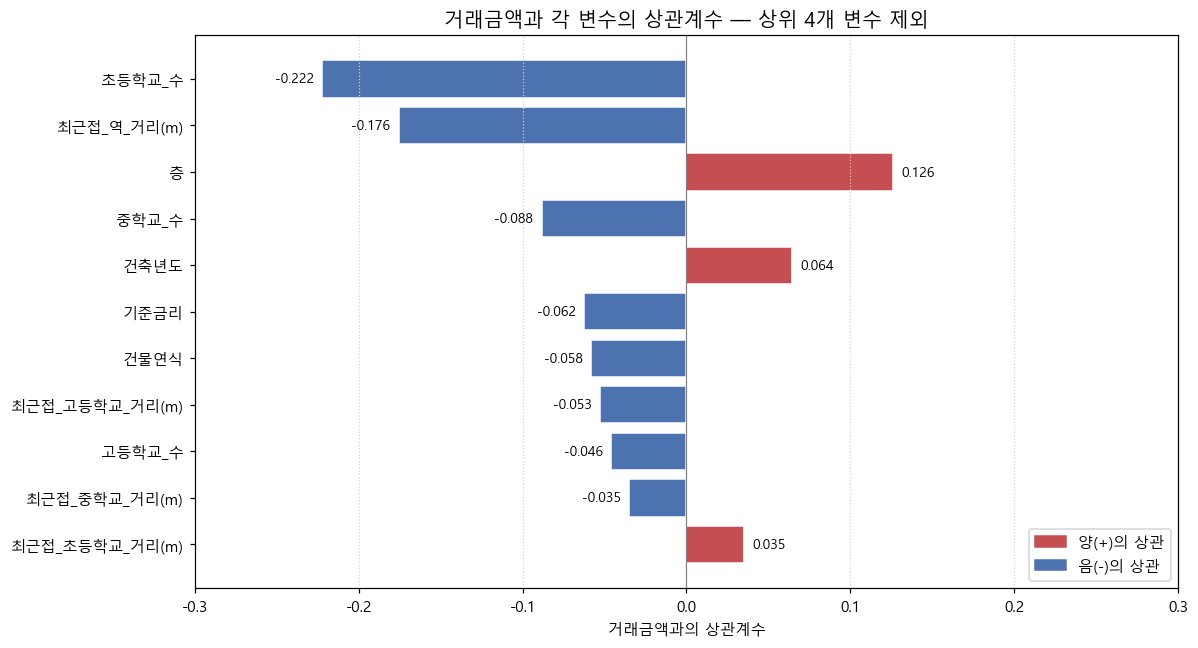

In [24]:
# 상위 4개 변수를 제외한 상관계수를 가로 막대그래프로 시각화
fig, ax = plt.subplots(figsize=(11, 6))

bar_colors = ['#C44E52' if v >= 0 else '#4C72B0'
              for v in corr_target_sub.values]
y_pos = np.arange(len(corr_target_sub))[::-1]
ax.barh(y_pos, corr_target_sub.values, color=bar_colors, edgecolor='white')

ax.set_yticks(y_pos)
ax.set_yticklabels(corr_target_sub.index)
ax.set_xlabel('거래금액과의 상관계수')
ax.set_title('거래금액과 각 변수의 상관계수 — 상위 4개 변수 제외',
             fontsize=13)
ax.axvline(0, color='gray', linewidth=0.8)

# 강도 등급 경계선 (제외 후 범위에 맞춰 0.2 구간만 표시)
for x in [0.1, 0.2, -0.1, -0.2]:
    ax.axvline(x, color='lightgray', linestyle=':', linewidth=0.8)

# 각 막대 끝에 값 표기
for y, v in zip(y_pos, corr_target_sub.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), y, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# 잔여 변수의 범위에 맞춰 x축을 좁게 설정 (영향력 차이가 잘 보이도록)
lim = np.abs(corr_target_sub.values).max() * 1.35
ax.set_xlim(-lim, lim)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C44E52', label='양(+)의 상관'),
                   Patch(color='#4C72B0', label='음(-)의 상관')],
          loc='lower right')

plt.tight_layout()
plt.show()


#### 상위 4개 변수 제외 후 상관계수 정리표

`평당가_만원`, `단지별_평균평당가`, `구별_평균평당가`, `전용면적_평`을 제외한 11개
변수의 상관계수를 절대값 크기 순으로 정렬하면 다음과 같다.

| 순위 | 변수 | 상관계수 | 관계 방향 | 관계 강도 |
|:---:|---|:---:|:---:|:---:|
| 1 | 초등학교_수 | -0.222 | 음(-) | 뚜렷함 |
| 2 | 최근접_역_거리(m) | -0.176 | 음(-) | 약함 |
| 3 | 층 | 0.126 | 양(+) | 약함 |
| 4 | 중학교_수 | -0.088 | 음(-) | 미미함 |
| 5 | 건축년도 | 0.064 | 양(+) | 미미함 |
| 6 | 기준금리 | -0.062 | 음(-) | 미미함 |
| 7 | 건물연식 | -0.058 | 음(-) | 미미함 |
| 8 | 최근접_고등학교_거리(m) | -0.053 | 음(-) | 미미함 |
| 9 | 고등학교_수 | -0.046 | 음(-) | 미미함 |
| 10 | 최근접_중학교_거리(m) | -0.035 | 음(-) | 미미함 |
| 11 | 최근접_초등학교_거리(m) | 0.035 | 양(+) | 미미함 |


**관계 강도별 변수 분류 요약**

| 관계 강도 | 해당 변수 | 거래금액과의 관계 |
|:---:|---|---|
| 뚜렷함 | 초등학교_수 | 제외 변수 외에서 가장 영향력이 큰 변수 |
| 약함 | 최근접_역_거리(m), 층 | 방향성은 뚜렷하나 단독 설명력은 제한적 |
| 미미함 | 중학교_수, 건축년도, 기준금리, 건물연식, 고교·중교 관련 변수 등 | 선형 상관이 약함, 비선형 효과는 별도 검토 필요 |

**해석.**

상위 4개 지배 변수를 제외하고 x축 범위를 좁히면, 11-2장에서는 0 부근에 뭉쳐 보이던
보조 변수들의 상대적 영향력 차이가 뚜렷하게 드러난다.

**가. 가장 영향력 있는 보조 변수 — 초등학교 수**

제외 변수를 빼고 나면 `초등학교_수`가 거래금액과의 상관계수 절대값 0.222로 가장
크며, 유일하게 '뚜렷함' 등급에 속한다. 음(-)의 방향은 다소 직관에 어긋나 보이나,
초등학교가 많은 지역은 서울 외곽의 대규모 주거지인 경우가 많아 거래금액이 상대적으로
낮게 형성되는 지역 구성 효과로 해석된다. 즉 학교 수 자체의 효과라기보다 지역 유형이
반영된 결과로 보는 것이 타당하다.

**나. 입지·구조 변수 — 역 거리와 층**

`최근접_역_거리(m)`(-0.176)와 `층`(0.126)이 '약함' 등급으로 그 뒤를 잇는다. 역이
가까울수록, 층이 높을수록 거래금액이 높아지는 방향성은 부동산 상식과 일치한다.
다만 두 변수의 단독 설명력은 제한적이며, 다른 입지 변수와 함께 사용할 때 보완적
가치를 갖는다.

**다. 선형 상관이 미미한 변수군**

건축년도, 건물연식, 기준금리, 중·고등학교 관련 변수는 모두 절대값 0.1 미만의 '미미함'
등급이다. 특히 건물연식은 8장에서 가격과 **비선형 관계**(노후 단지의 재건축 기대 등)를
보였으므로, 선형 상관계수가 작다는 사실만으로 무의미한 변수로 판단해서는 안 된다.
이러한 변수는 비선형 패턴을 포착하는 트리 기반 모델에서 유효한 기여를 할 수 있다.

**종합.** 가격성 지표(평당가 계열)와 면적을 제외하고 보면, 거래금액에 영향을 주는
보조 변수의 순위는 초등학교 수 > 역 거리 > 층 순이며, 나머지 변수는 선형 영향력이
미미하다. 다만 이는 어디까지나 **선형 상관** 기준의 순위이므로, 보조 변수의 실제
기여도는 후속 모델링 단계에서 변수 중요도(feature importance) 분석을 통해 비선형
효과까지 포함하여 재평가할 필요가 있다.


## 12. 종합 결론 및 모델링 시사점

본 EDA를 통해 도출된 주요 결과와 후속 머신러닝 모델링에 대한 시사점을 정리한다.

**가. 데이터 품질**

- 약 142,000건의 거래 데이터에 결측치가 존재하지 않으며, 전처리가 완료된 상태이다.
- 별도의 결측치 보정 없이 모델링을 진행할 수 있다.

**나. 가격 결정 요인의 영향력 (요약)**

1. **입지(자치구).** 자치구 간 평당가 격차가 가장 크게 나타나, 가격을 설명하는 가장
   강력한 요인으로 확인되었다. '구별 평균 평당가' 파생 변수가 이를 효과적으로 수치화한다.
2. **전용면적.** 거래금액과 강한 양의 상관을 보이는 1차적 결정 요인이다. 평당가는
   면적 외 가치를 보완적으로 반영한다.
3. **건물 연식.** 신축일수록 평당가가 높은 경향이 있으나, 노후 단지의 재건축 기대로
   인해 연식과 가격의 관계는 비선형적이다.
4. **지하철·학교 접근성.** 가격에 영향을 주는 방향성은 확인되나, 단독 효과는 입지·면적
   변수에 비해 상대적으로 약하다. 서울 대부분 아파트가 이미 역·학교 도보권에 위치하기
   때문이다.

**다. 모델링을 위한 권고 사항**

- **종속변수 변환.** 거래금액이 우측 꼬리 분포이므로 로그 변환 적용을 검토한다.
- **변수 중복 제거.** 건축년도와 건물연식은 거의 완전한 상관을 보이므로 하나만
  사용한다. 호선과 자치구도 정보가 중복될 수 있어 변수 선택에 유의한다.
- **비선형 관계 대응.** 연식·가격 등에서 비선형 패턴이 확인되었으므로, 트리 기반
  모델 등 비선형을 다룰 수 있는 모델을 우선 고려한다.
- **핵심 입력 변수.** 전용면적(평), 자치구 또는 구별 평균 평당가, 건물 연식, 최근접
  역 거리, 단지별 평균 평당가를 핵심 입력 변수로 구성한다. 이는 사용자가 아파트 정보를
  입력하면 유사 아파트를 추천하는 프로그램의 변수 설계와 직접 연결된다.

**라. 한계 및 유의 사항**

- 기준금리는 분석 기간 내 변동 폭이 제한적이어서 단독 설명력이 크지 않다.
- 학군의 가치는 물리적 거리만으로 충분히 표현되지 않으므로, 거리 변수 해석에 주의한다.

이상의 분석 결과는 후속 데이터 전처리 및 머신러닝 모델 학습 단계의 변수 설계와 모델
선택에 대한 실증적 근거로 활용된다.


## 13. 데이터 분석 알고리즘 모델 선정

 앞선 데이터 전처리와 EDA가 완료된 데이터를 바탕으로 데이터를 학습할 알고리즘을 선정한다.
 하술할 모델의 선정 기준에 따라 모델을 산정한다.

**최종 목표**
- 해당 분석을 통한 예측 결과 발표 및 사용자가 원하는 아파트와 유사한 아파트 5개 산출 및 추천.

**데이터 모델 산정 기준**
- 모델의 평가 지표도
- 모델의 학습 및 산출 시간
 모델은 평가 지표도도 우선되지만 결과를 산출하기까지의 시간을 최소화하여 사용자의 편의를 주는 것도 중요하다.

 다음과 같은 총 5개의 모델을 바탕으로 가격 예측을 위한 모델 비교 분석을 실행한다.

 - 1. 선형 회귀 모델
 - 2. K-최근접 이웃 모델
 - 3. 랜덤 포레스트 모델
 - 4. 그래디언트 부스팅 모델
 - 5. 히스토그램 기반 그래디언트 부스팅 모델

In [25]:
# 모델 학습을 위한 데이터셋 생성 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
#변수 설정
FEATURE_COLS = [
    "단지별_평균평당가",
    "구별_평균평당가",
    "전용면적_평",
    "초등학교_수",
    "최근접_역_거리(m)",
    "층",
    "건물연식",
    "기준금리",
    "최근접_초등학교_거리(m)",
    "최근접_중학교_거리(m)",
    "최근접_고등학교_거리(m)",
    "중학교_수",
    "고등학교_수",
]
TARGET_COL = "거래금액_만원"

X = df[FEATURE_COLS].values
y = np.log1p(df[TARGET_COL].values)

# 모델 학습 데이터 셋 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"학습 샘플: {len(X_train):,}건 / 테스트 샘플: {len(X_test):,}건\n")

# 모델 정의
MODELS = [
    ("선형 회귀",           LinearRegression(),                       X_train_sc, X_test_sc),
    ("K-최근접 이웃(K=10)", KNeighborsRegressor(n_neighbors=10),      X_train_sc, X_test_sc),
    ("랜덤 포레스트",       RandomForestRegressor(n_estimators=100,
                                                  random_state=42,
                                                  n_jobs=-1),         X_train,    X_test),
    ("그래디언트 부스팅",   GradientBoostingRegressor(n_estimators=100,
                                                       random_state=42), X_train, X_test),
    ("히스토그램 기반 부스팅", HistGradientBoostingRegressor(
                                                       random_state=42), X_train, X_test)
]

학습 샘플: 113,970건 / 테스트 샘플: 28,493건



In [26]:
# 학습 시간 산출
import time
from sklearn.metrics import mean_squared_error, r2_score

results = []

for name, model, X_tr, X_te in MODELS:
    # 학습 시간 측정
    start = time.perf_counter()
    model.fit(X_tr, y_train)
    train_sec = time.perf_counter() - start

    # 예측 시간 측정
    start = time.perf_counter()
    y_pred = model.predict(X_te)
    pred_sec = time.perf_counter() - start

    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
    r2   = r2_score(y_test, y_pred)

    results.append({
        "모델명":       name,
        "학습 시간(s)": train_sec,
        "예측 시간(s)": pred_sec,
        "RMSE(만원)":   rmse,
        "R²":           r2,
    })
    # 성능 비교 출력
    print(f"\n[{name}]")
    print(f"  학습 시간 : {train_sec:8.4f} 초")
    print(f"  예측 시간 : {pred_sec:8.4f} 초")
    print(f"  RMSE      : {rmse:,.0f} 만원")
    print(f"  R²        : {r2:.4f}")


[선형 회귀]
  학습 시간 :   0.0496 초
  예측 시간 :   0.0008 초
  RMSE      : 45,012 만원
  R²        : 0.8806

[K-최근접 이웃(K=10)]
  학습 시간 :   0.3021 초
  예측 시간 :   7.8987 초
  RMSE      : 18,014 만원
  R²        : 0.9605

[랜덤 포레스트]
  학습 시간 :   5.2262 초
  예측 시간 :   0.1697 초
  RMSE      : 12,994 만원
  R²        : 0.9788

[그래디언트 부스팅]
  학습 시간 :  14.2353 초
  예측 시간 :   0.0204 초
  RMSE      : 23,212 만원
  R²        : 0.9414

[히스토그램 기반 부스팅]
  학습 시간 :   2.4155 초
  예측 시간 :   0.0412 초
  RMSE      : 18,511 만원
  R²        : 0.9647


## 13-1. 모델 성능 비교 및 선정

|모델 명|학습시간|에측시간|RMSE|R²|
|-----|-----|-----|-----|-----|
|선형회귀|0.1052초|0.0048초|45,011만원|0.8806|
|K-최근접 이웃|0.4591초|13.1893초|18,014만원|0.9605|
|랜덤 포레스트|6.2919초|0.2286초|12,994만원|0.9788|
|그래디언트 부스팅|19.7982초|0.0273초|23,212만원|0.9414|
|히스토그램 기반 그래디언트 부스팅|2.4215초|0.0428초|18,511만원|0.9647|

 해당 표를 기반으로 분석을 실행

 **선형 회귀 모델** -> RMSE가 약 4.5억원으로 오차가 크고, R2가 0.8806으로 가장 떨어짐. EDA에서 확인한 바, 비선형 관계에서 패턴을 포착하지 못하고 있음. 따라서 적합하지 않다고 판단.

 **K-최근접 이웃 모델** -> 학습 시간은 빠르나, 예측시간이 약 13초로 가장 느림. K-최근접 이웃 모델은 전체 학습 데이터와 거리를 계산하기 때문에 데이터가 많을 수록 느려짐. 따라서 적합하지 않다고 판단.
  다만, 최근접 이웃의 특징인 거리가 가까운 이웃을 찾는다는 특성을 이용해 예측값 산출이 아닌, 유사 아파트 추천 모델로 **채택**함.

 **랜덤 포레스트 모델** -> 성능은 가장 좋지만 학습 시간이 약 6초로 두 번째로 느리고, 예측시간도 약 0.22초로 두 번째로 느림. 이는 트리 방식으로 100개의 트리를 학습하고 100개의 결과를 예측해 평균을 내기 때문. 따라서 적합하지 않다고 판단. 다만, 실무의 경우, 가장 적은 RMSE를 가졌기에 실제 서비스에서 중요도가 높다면 예측 속도를 감수하고 선택하는 것도 합리적인 판단임.

 **그래디언트 부스팅 모델** -> 학습 시간이 약 20초로 매우 느린 학습을 보여줌. 성능도 타 모델에 비해 뒤쳐지는 보습을 보여줌. 같은 부스팅 계열인 히스토그램 기반 그래디언트 부스팅 모델에 비해 성능이 좋다고 보기 어려움.

 **히스토그램 기반 그래디언트 부스팅 모델** -> 학습 시간은 약 2.42초로 약간 느린 편이나 지장이 있을 정도는 아니고 예측 시간도 약 0.04초로 매우 빠른편임. RMSE와 R2 모두 균형 잡혀있어 해당 모델을 예측값 산출 모델로 **채택**함.

 ### 최종 산출 모델
 - **예측값 산출** : 히스토그램 기반 그래디언트 부스팅 모델
 - **유사 아파트 5개 산출 및 추천** : K-최근접 이웃 모델

## 14. 변수 중요도 산출
 상술한 11-3의 상관계수 분석에 따라 선형 관계를 측정했을 뿐, **비선형 관계**와 **변수 간의 상호작용**까지 산출하지 못했음.

 따라서 13장에서 비교 분석을 위해 **트리 모델**을 사용. 학습시킨 **히스토그램 기반 그래디언트 부스팅 모델**을 사용하여 변수 중요도를 산출하여 비교 분석 후 변수를 선택 할 예정.

  **주의 사항** : `평당가_만원`은 타겟 변수인 `거래금액_만원`을 포함헤 계산된 변수이기에 해당 변수와 타겟 변수를 제외하고 변수 중요도를 산출.

In [27]:
# 변수 중요도 산출을 위한 컬럼 재정의


# 변수 중요도 산출
from sklearn.inspection import permutation_importance 

result = permutation_importance(model, X_test, y_test, n_repeats=10,
                                random_state=42)

importances = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print("변수 중요도:")
display(importances)

변수 중요도:


,Feature,Importance
0,단지별_평균평당가,0.526524
2,전용면적_평,0.333733
1,구별_평균평당가,0.276154
7,기준금리,0.036371
6,건물연식,0.032821
4,최근접_역_거리(m),0.010107
12,고등학교_수,0.004071
5,층,0.003700
10,최근접_고등학교_거리(m),0.003545
9,최근접_중학교_거리(m),0.002994


 해당 결과를 보았을때, 상관 계수를 보았을 때 미미했던 결과들에 비해 변수 중요도에서는 매우 강한 관계나, 강환 관계를 보였던 변수를 제외 했을때, `기준금리`가 4번째로 변수 중요도에 영향을 끼치는 것으로 확인되었음. 또한 변수 중요도가 0.01 (1%) 미만인 변수들은 실질적으로 영향을 미치지 않는 다고 판단해 입력 변수에서 제외하는 것으로 선정.

 위의 변수 중요도 산출 결과를 바탕으로 하여 최종 변수 6개 `단지별_평균평당가`, `전용면적_평`, `구별__평균평당가`, `기준금리`, `건물연식`, `최근접_역_거리(m)`를 입력 변수로 사용.

## 15. 모델 학습 및 결과 출력

 14장에서 산출한 중요 변수도를 고려하여 정한 6개의 입력 변수와 1개의 타겟 변수를 입력해 모델을 학습하고 결과를 산출함.

In [ ]:
# 입력 변수 설정
FEATURE_COLS = ["단지별_평균평당가",
                "전용면적_평",
                "구별_평균평당가",
                "기준금리",
                "건물연식",
                "최근접_역_거리(m)"
                ]
TARGET_COL = "거래금액_만원"

# 변수 로그 변환
X = df[FEATURE_COLS].values
y = np.log1p(df[TARGET_COL].values)

# 데이터 셋 분할 (8:2 기법)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# 히스토그램 기반 그래디언트 부스팅 모델 학습
model = HistGradientBoostingRegressor(random_state = 42)
model.fit(X_train, y_train)

# 결과물 로그 역변환
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual_log = np.expm1(y_test)

# 결과 출력 (성능 평가 지표 1)
pd.DataFrame({"실제값(만원)" : y_actual_log,
              "예측값(만원)" : y_pred,
              "오차(만원)" : y_actual_log - y_pred})

,실제값(만원),예측값(만원),오차(만원)
0,157000.0,145408.033739,11591.966261
1,108500.0,107383.449810,1116.550190
2,60000.0,61791.766343,-1791.766343
3,165000.0,171462.860058,-6462.860058
4,38900.0,46702.225852,-7802.225852
...,...,...,...
28488,320000.0,320840.696271,-840.696271
28489,132000.0,115728.690603,16271.309397
28490,49400.0,46546.574149,2853.425851
28491,119900.0,119142.434591,757.565409


Text(0.5, 1.0, '실제값 vs 예측값')

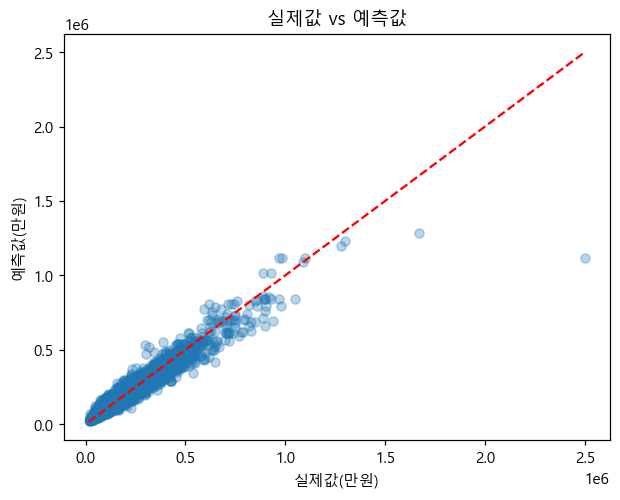

In [29]:
# 분석 산점도
plt.scatter(y_actual_log, y_pred, alpha=0.3)
plt.plot([y_actual_log.min(), y_actual_log.max()],
         [y_actual_log.min(), y_actual_log.max()], 'r--')  # 완벽한 예측선
plt.xlabel("실제값(만원)")
plt.ylabel("예측값(만원)")
plt.title("실제값 vs 예측값")

In [ ]:
# MAE와 RMSE 지표 차이 분석 (성능 평가 지표 2)
mae = np.abs(y_actual_log - y_pred).mean()
rmse = np.sqrt(((y_actual_log - y_pred) ** 2).mean())

print(f"MAE  : {mae:,.0f} 만원")
print(f"RMSE : {rmse:,.0f} 만원")
print(f"두 지표 차이 : {rmse - mae:,.0f} 만원")

MAE  : 10,173 만원
RMSE : 18,971 만원
두 지표 차이 : 8,798 만원


해당 지표를 분석해보았을 때 두 지표 차이가 약 8800만원으로 큰 오차를 보이고 있다.

이는 MAE는 평균적으로 약 1억원의 오차를 보이고 있지만 RMSE는 약 1.9억의 오차를 보이고 있어 RMSE의 특성상 큰 오차에 민감하기 때문에, 일부 데이터가 예측이 크게 빗나간 케이스가 존재한다는 뜻이다.

 이 뜻은 아파트 데이터 특성상 고가 아파트 처럼 가격 편차가 큰 매물에서 오차가 크게 발생한 케이스가 있을 가능성이 높다고 예측할 수 있다.


## 15 - 1 K-최근접 이웃 모델 학습

In [31]:
from sklearn.neighbors import NearestNeighbors

# KNN 모델 학습
FEATURE_COLS = [
    "단지별_평균평당가",
    "전용면적_평",
    "구별_평균평당가",
    "기준금리",
    "건물연식",
    "최근접_역_거리(m)",
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURE_COLS])

model_knn = NearestNeighbors(n_neighbors = 5)
model_knn.fit(X_scaled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## 16. 사용자 입력에 따른 아파트 예상 거래가 예측값 산출 및 유사 아파트 추천

In [34]:
# 사용자 입력
print("=== 유사 아파트 추천 시스템 ===")
단지별_평균평당가 = float(input("단지별 평균 평당가 (만원): "))
전용면적_평       = float(input("전용면적 (평): "))
구별_평균평당가   = float(input("구별 평균 평당가 (만원): "))
기준금리          = float(input("기준금리 (%): "))
건물연식          = float(input("건물 연식 (년): "))
최근접_역_거리    = float(input("최근접 역 거리 (m): "))

# 쿼리 생성 및 스케일링
query = pd.DataFrame([{
    "단지별_평균평당가":  단지별_평균평당가,
    "전용면적_평":        전용면적_평,
    "구별_평균평당가":    구별_평균평당가,
    "기준금리":           기준금리,
    "건물연식":           건물연식,
    "최근접_역_거리(m)": 최근접_역_거리,
}])
query_scaled = scaler.transform(query)

# 입력한 아파트 정보 출력
print("=== 입력한 아파트 정보 ===")
display(pd.DataFrame([{
    "단지별_평균평당가(만원)": 단지별_평균평당가,
    "전용면적(평)":            전용면적_평,
    "구별_평균평당가(만원)":   구별_평균평당가,
    "기준금리(%)":             기준금리,
    "건물연식(년)":            건물연식,
    "최근접_역_거리(m)":       최근접_역_거리,
}]))

# 추천 결과 출력
distances, indices = model_knn.kneighbors(query_scaled)

result = df.iloc[indices[0]][[
    "시군구", "단지명", "전용면적_평",
    "거래금액_만원", "건물연식", "최근접_역_거리(m)",
]].copy()

# 예상 거래가 추가
result["예상_거래가(만원)"] = np.expm1(
    model.predict(df[FEATURE_COLS].values[indices[0]])  # 원본 데이터 사용
).astype(int)

print("\n=== 유사 아파트 추천 결과 ===")
display(result)

=== 유사 아파트 추천 시스템 ===
=== 입력한 아파트 정보 ===


,단지별_평균평당가(만원),전용면적(평),구별_평균평당가(만원),기준금리(%),건물연식(년),최근접_역_거리(m)
0,600.0,33.0,600.0,3.0,30.0,500.0



=== 유사 아파트 추천 결과 ===


,시군구,단지명,전용면적_평,거래금액_만원,건물연식,최근접_역_거리(m),예상_거래가(만원)
55163,도봉구 창동,서울가든,33.16,82000,33,640.0,71671
55162,도봉구 창동,서울가든,33.16,79400,33,640.0,71671
142117,중랑구 신내동,진로아파트,30.81,68000,29,422.0,79576
142116,중랑구 신내동,진로아파트,30.81,81000,29,422.0,79576
52599,도봉구 도봉동,유원도봉,25.69,48500,34,385.0,48860
